# 🌾 Intelligent Crop Recommendation System
---
| | |
|---|---|
| **Dataset** | IEEE DataPort – Crop Recommendation (18,079 samples) |
| **Features** | Nitrogen · Phosphorus · Potassium · pH · Rainfall · Temperature |
| **Target** | 40 Crop Classes |
| **Models** | Decision Tree · Random Forest · KNN · SVM · Naive Bayes |
| **XAI** | SHAP (full dataset, tree-path method) · LIME (full test set, batch) |
| **Source** | https://ieee-dataport.org/documents/crop-recommendation-dataset |

## 📦 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Ridge
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

np.random.seed(42)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

FEATURES = ['N', 'P', 'K', 'pH', 'rainfall', 'temperature']
FLABELS  = ['Nitrogen (N)', 'Phosphorus (P)', 'Potassium (K)',
             'pH', 'Rainfall', 'Temperature']
COLORS   = ['#3498DB','#2ECC71','#E74C3C','#9B59B6','#F39C12','#1ABC9C']

print('✅  All libraries imported successfully!')

✅  All libraries imported successfully!


## 📂 2. Load Dataset

In [2]:
# NOTE: only Train_Dataset.csv is needed — we split it 80/20 internally
df = pd.read_csv('Train_Dataset.csv')
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

print(f'Dataset shape : {df.shape}')
print(f'Crop classes  : {df["Crop"].nunique()}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'\nClass list: {sorted(df["Crop"].unique())}')
df.head(8)

Dataset shape : (18079, 7)
Crop classes  : 40
Missing values: 0

Class list: ['banana', 'barley', 'bittergourd', 'blackgram', 'blackpepper', 'bottlegourd', 'brinjal', 'cabbage', 'cardamom', 'cauliflower', 'coriander', 'cotton', 'cucumber', 'drumstick', 'garlic', 'grapes', 'horsegram', 'jackfruit', 'jowar', 'jute', 'ladyfinger', 'maize', 'mango', 'moong', 'onion', 'orange', 'papaya', 'pineapple', 'potato', 'pumpkin', 'radish', 'ragi', 'rapeseed', 'rice', 'soyabean', 'sunflower', 'sweetpotato', 'tomato', 'turmeric', 'wheat']


,Crop,N,P,K,pH,rainfall,temperature
0,barley,70,40,45,5.54,75.320,22.676000
1,sunflower,50,60,30,5.54,297.660,29.566667
2,sweetpotato,90,20,120,5.02,689.880,29.037273
3,rice,80,40,40,5.66,297.660,29.566667
4,soyabean,20,60,20,5.38,1011.490,30.430000
5,jowar,80,40,40,5.52,1246.715,22.600000
6,potato,180,60,90,5.08,1026.640,29.186364
7,rice,80,40,40,5.40,840.460,33.583333


---
## 📊 3. Exploratory Data Analysis
### 3a. Statistical Summary

In [3]:
display(df[FEATURES].describe().round(3))
print('\nData types:')
print(df.dtypes)

,N,P,K,pH,rainfall,temperature
count,18079.000,18079.000,18079.000,18079.000,18079.000,18079.000
mean,72.684,43.489,41.608,5.581,661.896,26.497
std,40.020,14.051,27.585,0.477,578.162,4.970
min,10.000,10.000,10.000,3.820,3.275,1.180
25%,50.000,40.000,20.000,5.340,127.680,22.891
50%,80.000,40.000,30.000,5.500,579.750,26.736
75%,80.000,60.000,50.000,5.680,1037.320,29.186
max,180.000,125.000,200.000,7.000,3322.060,35.347



Data types:
Crop               str
N                int64
P                int64
K                int64
pH             float64
rainfall       float64
temperature    float64
dtype: object


### 3b. Feature Distributions

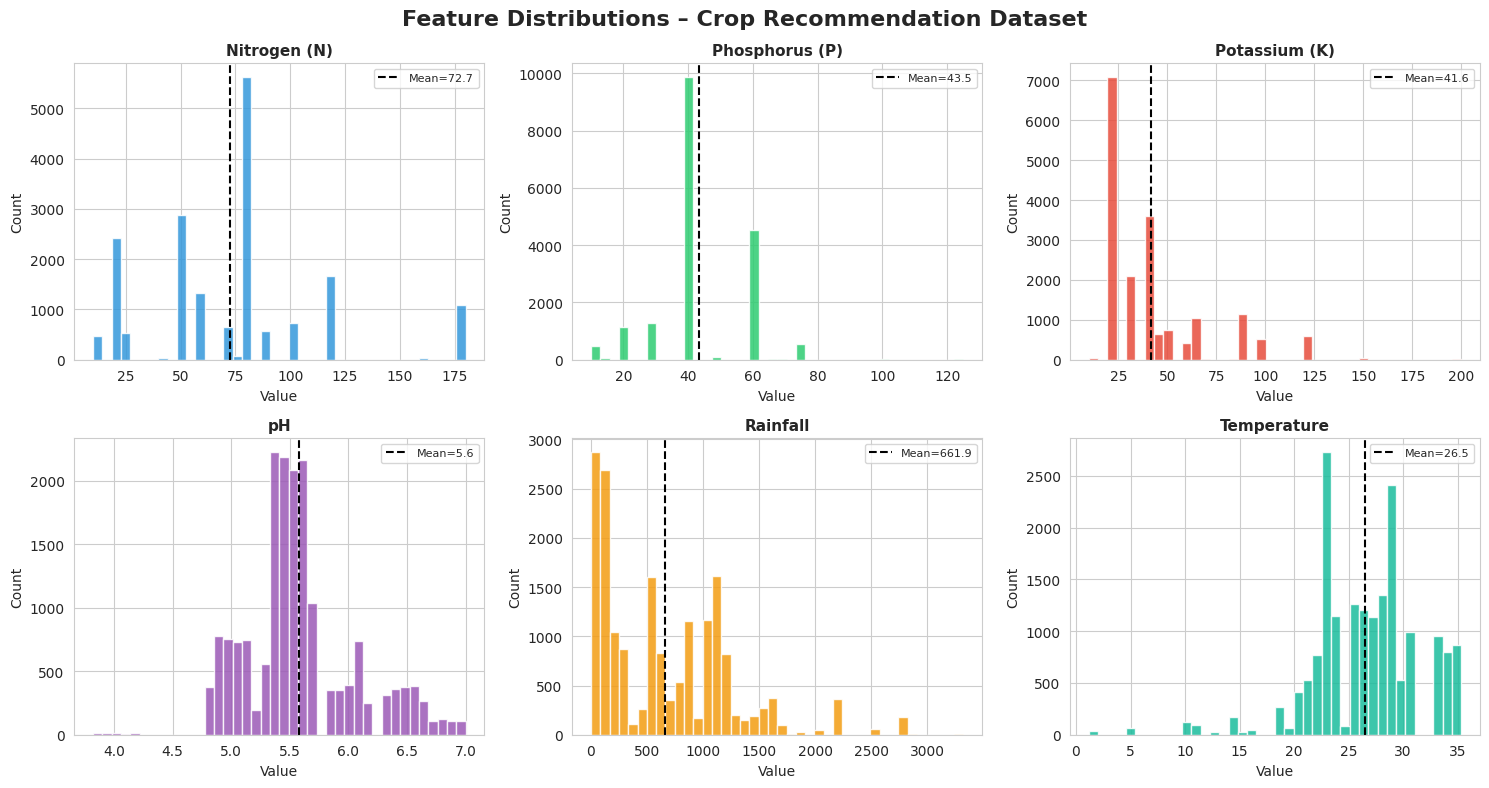

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions – Crop Recommendation Dataset',
             fontsize=16, fontweight='bold')
for ax, feat, lbl, col in zip(axes.flatten(), FEATURES, FLABELS, COLORS):
    ax.hist(df[feat], bins=40, color=col, edgecolor='white', alpha=0.85)
    ax.set_title(lbl, fontweight='bold', fontsize=11)
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.axvline(df[feat].mean(), color='black', ls='--', lw=1.5,
               label=f'Mean={df[feat].mean():.1f}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 3c. Crop Class Distribution

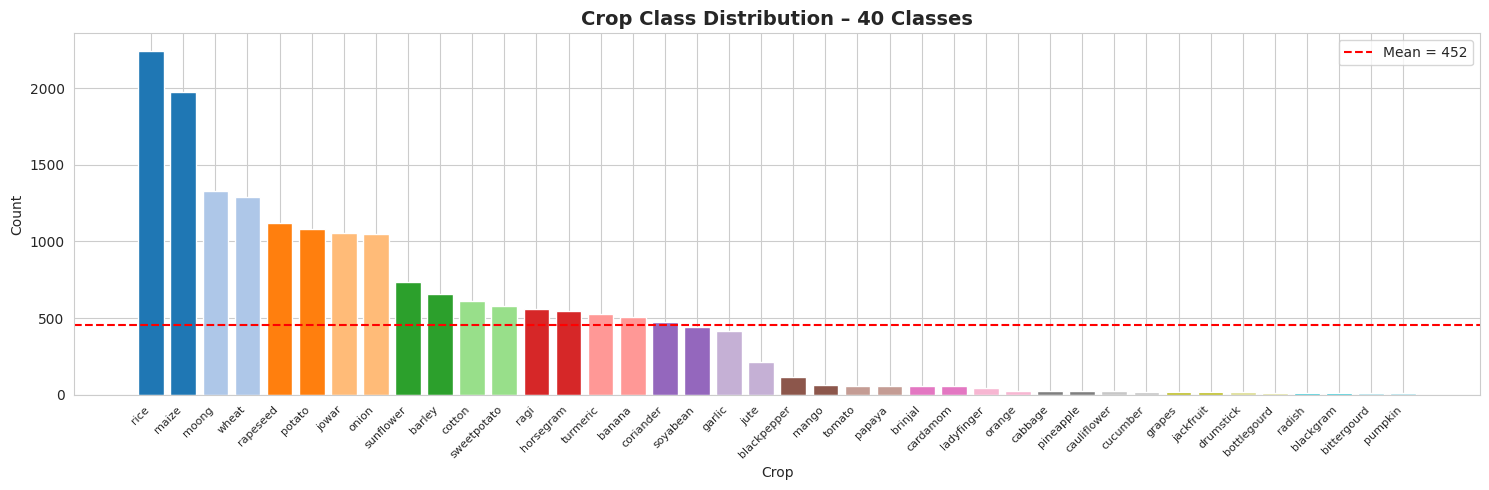

In [5]:
fig, ax = plt.subplots(figsize=(15, 5))
crop_counts = df['Crop'].value_counts().sort_values(ascending=False)
bar_colors  = plt.cm.tab20(np.linspace(0, 1, len(crop_counts)))
ax.bar(crop_counts.index, crop_counts.values, color=bar_colors, edgecolor='white')
ax.set_title('Crop Class Distribution – 40 Classes', fontsize=14, fontweight='bold')
ax.set_xlabel('Crop'); ax.set_ylabel('Count')
ax.axhline(crop_counts.mean(), color='red', ls='--', lw=1.5,
           label=f'Mean = {crop_counts.mean():.0f}')
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

### 3d. Boxplots & Outlier Analysis

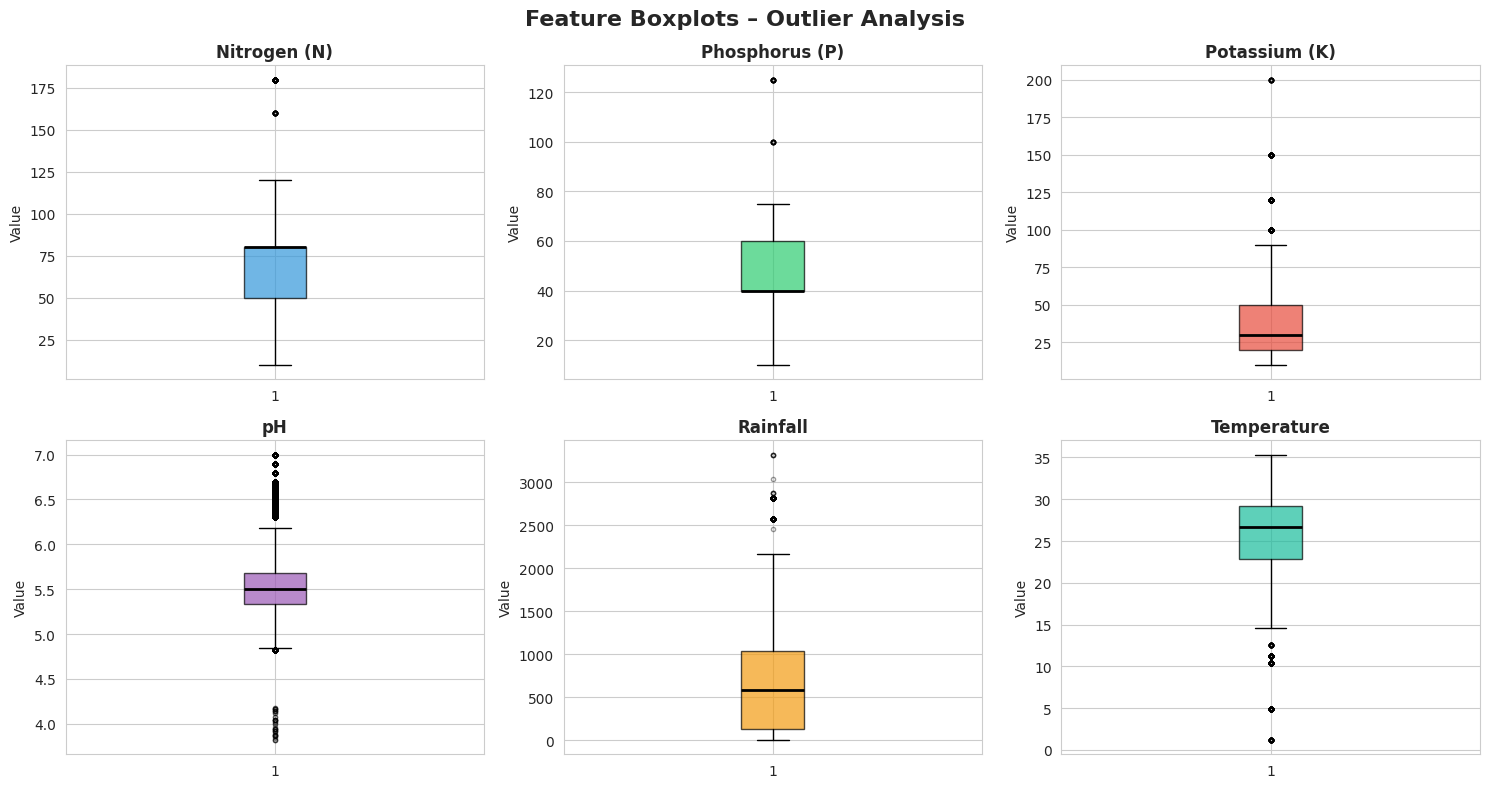

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Boxplots – Outlier Analysis', fontsize=16, fontweight='bold')
for ax, feat, lbl, col in zip(axes.flatten(), FEATURES, FLABELS, COLORS):
    ax.boxplot(df[feat], vert=True, patch_artist=True,
               boxprops=dict(facecolor=col, alpha=0.7),
               medianprops=dict(color='black', lw=2),
               flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(lbl, fontweight='bold')
    ax.set_ylabel('Value')
plt.tight_layout()
plt.show()

### 3e. Correlation Heatmap

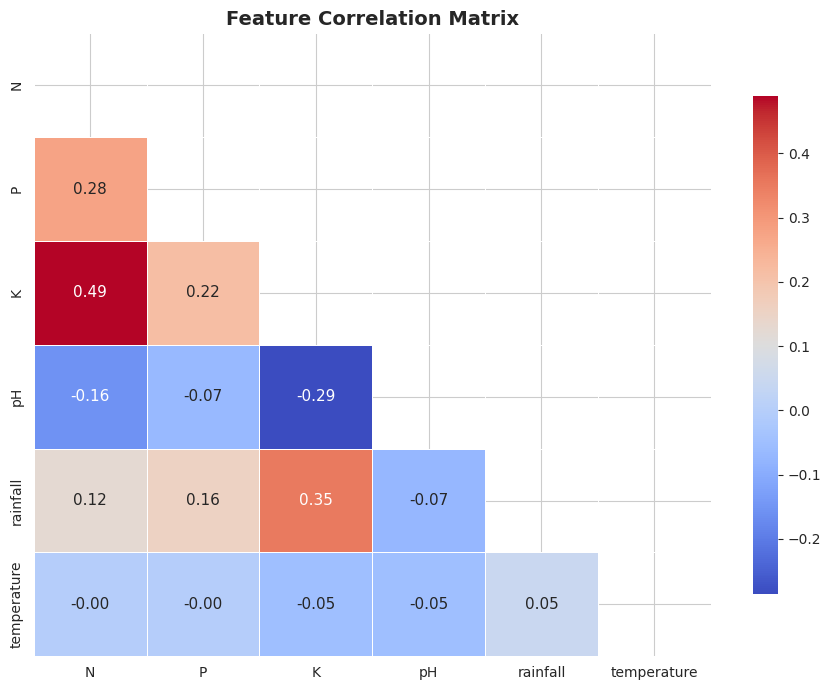

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            mask=mask, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 11})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⚙️ 4. Data Preprocessing

In [8]:
# Encode target labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['Crop'])

X = df[FEATURES].values
y = df['label'].values

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardise for distance/kernel models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train samples : {X_train.shape[0]}')
print(f'Test  samples : {X_test.shape[0]}')
print(f'Features      : {X_train.shape[1]}')
print(f'Classes       : {len(le.classes_)}')
print(f'\nLabel mapping (first 8):')
for crop, num in zip(le.classes_[:8], range(8)):
    print(f'  {crop:<20s} → {num}')
print('  ...')

Train samples : 14463
Test  samples : 3616
Features      : 6
Classes       : 40

Label mapping (first 8):
  banana               → 0
  barley               → 1
  bittergourd          → 2
  blackgram            → 3
  blackpepper          → 4
  bottlegourd          → 5
  brinjal              → 6
  cabbage              → 7
  ...


---
## 🤖 5. Model Training
Train Decision Tree · Random Forest · KNN · SVM · Naive Bayes

In [9]:
models_cfg = {
    'Decision Tree' : (DecisionTreeClassifier(random_state=42),
                       X_train,    X_test),
    'Random Forest' : (RandomForestClassifier(n_estimators=150,
                                              random_state=42, n_jobs=-1),
                       X_train,    X_test),
    'KNN'           : (KNeighborsClassifier(n_neighbors=5),
                       X_train_sc, X_test_sc),
    'SVM'           : (SVC(kernel='rbf', C=10, gamma='scale',
                           probability=True, random_state=42),
                       X_train_sc, X_test_sc),
    'Naive Bayes'   : (GaussianNB(),
                       X_train,    X_test),
}

results        = {}
y_preds        = {}
trained_models = {}

for name, (model, Xtr, Xte) in models_cfg.items():
    model.fit(Xtr, y_train)
    yp = model.predict(Xte)
    results[name] = dict(
        Accuracy =accuracy_score(y_test, yp),
        Precision=precision_score(y_test, yp, average='weighted', zero_division=0),
        Recall   =recall_score(y_test, yp, average='weighted', zero_division=0),
        F1_Score =f1_score(y_test, yp, average='weighted', zero_division=0),
    )
    y_preds[name]        = yp
    trained_models[name] = model
    print(f'{name:20s}  '
          f'Acc={results[name]["Accuracy"]:.4f}  '
          f'F1={results[name]["F1_Score"]:.4f}')

df_results = (pd.DataFrame(results).T
              .rename(columns={'F1_Score': 'F1-Score'})
              .sort_values('F1-Score', ascending=False))
best_name = df_results.index[0]
print(f'\n🏆  Best model: {best_name}')

Decision Tree         Acc=0.9331  F1=0.9334
Random Forest         Acc=0.9339  F1=0.9327
KNN                   Acc=0.9303  F1=0.9292
SVM                   Acc=0.9298  F1=0.9025
Naive Bayes           Acc=0.9270  F1=0.8997

🏆  Best model: Decision Tree


---
## 📊 6. Model Evaluation

In [10]:
display(df_results.style
        .background_gradient(cmap='YlGn')
        .format('{:.4f}')
        .set_caption('All Models – Sorted by F1-Score'))

,Accuracy,Precision,Recall,F1-Score
Decision Tree,0.9331,0.9338,0.9331,0.9334
Random Forest,0.9339,0.9321,0.9339,0.9327
KNN,0.9303,0.9293,0.9303,0.9292
SVM,0.9298,0.8850,0.9298,0.9025
Naive Bayes,0.9270,0.8824,0.9270,0.8997


### 6b. Best Model Classification Report

In [11]:
print(f'=== {best_name} – Full Classification Report ===')
print(classification_report(y_test, y_preds[best_name],
                             target_names=le.classes_))

=== Decision Tree – Full Classification Report ===
              precision    recall  f1-score   support

      banana       1.00      1.00      1.00       101
      barley       1.00      1.00      1.00       131
 bittergourd       1.00      1.00      1.00         2
   blackgram       1.00      1.00      1.00         2
 blackpepper       1.00      1.00      1.00        24
 bottlegourd       1.00      1.00      1.00         3
     brinjal       1.00      1.00      1.00        11
     cabbage       1.00      1.00      1.00         5
    cardamom       1.00      1.00      1.00        11
 cauliflower       1.00      1.00      1.00         5
   coriander       1.00      1.00      1.00        95
      cotton       1.00      1.00      1.00       123
    cucumber       1.00      1.00      1.00         4
   drumstick       1.00      1.00      1.00         3
      garlic       1.00      1.00      1.00        83
      grapes       1.00      1.00      1.00         4
   horsegram       1.00      1

### 6c. Model Comparison Bar Chart

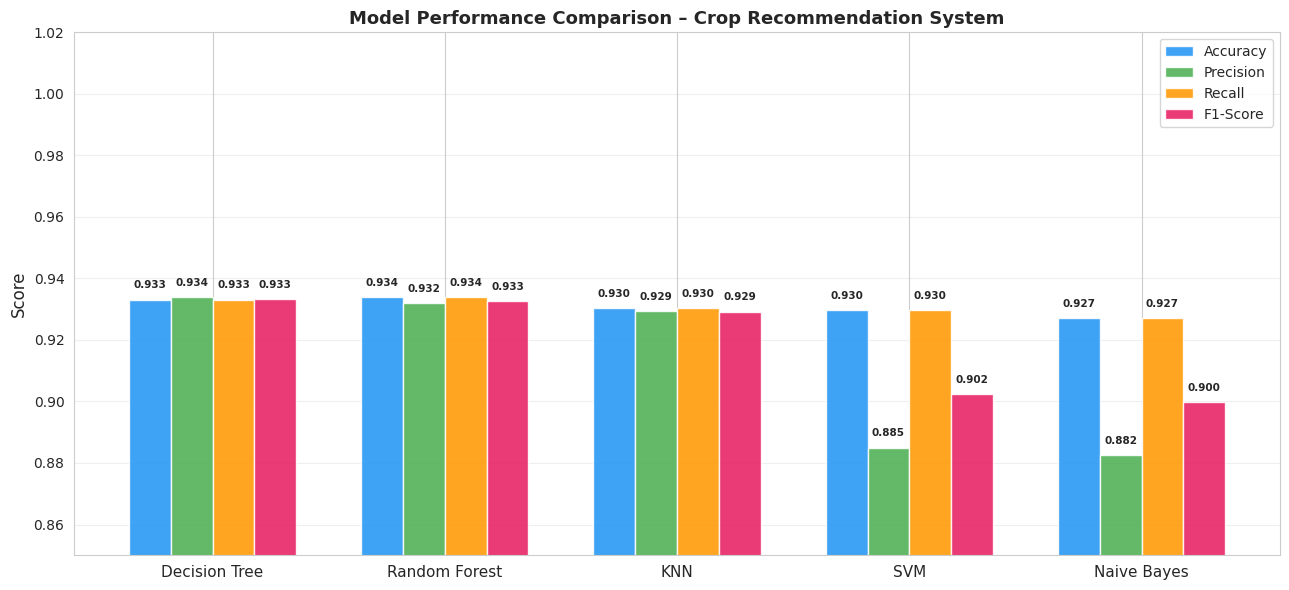

In [12]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x       = np.arange(len(df_results))
w       = 0.18
palette = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics, palette)):
    bars = ax.bar(x + i*w, df_results[metric], w,
                  label=metric, color=color, alpha=0.87, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(df_results.index, fontsize=11)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison – Crop Recommendation System',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 6d. Radar Chart

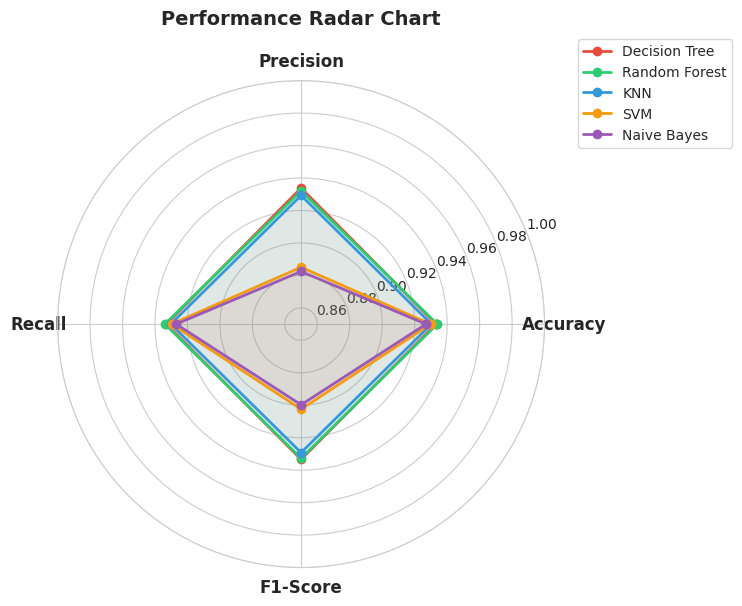

In [13]:
N_met  = len(metrics)
angles = [n / float(N_met) * 2 * np.pi for n in range(N_met)] + [0]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
pal = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6']
for (name, row), color in zip(df_results.iterrows(), pal):
    vals = row[metrics].tolist() + [row[metrics[0]]]
    ax.plot(angles, vals, 'o-', lw=2, color=color, label=name)
    ax.fill(angles, vals, alpha=0.07, color=color)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.set_ylim(0.85, 1.00)
ax.set_title('Performance Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

### 6e. Confusion Matrix – Best Model

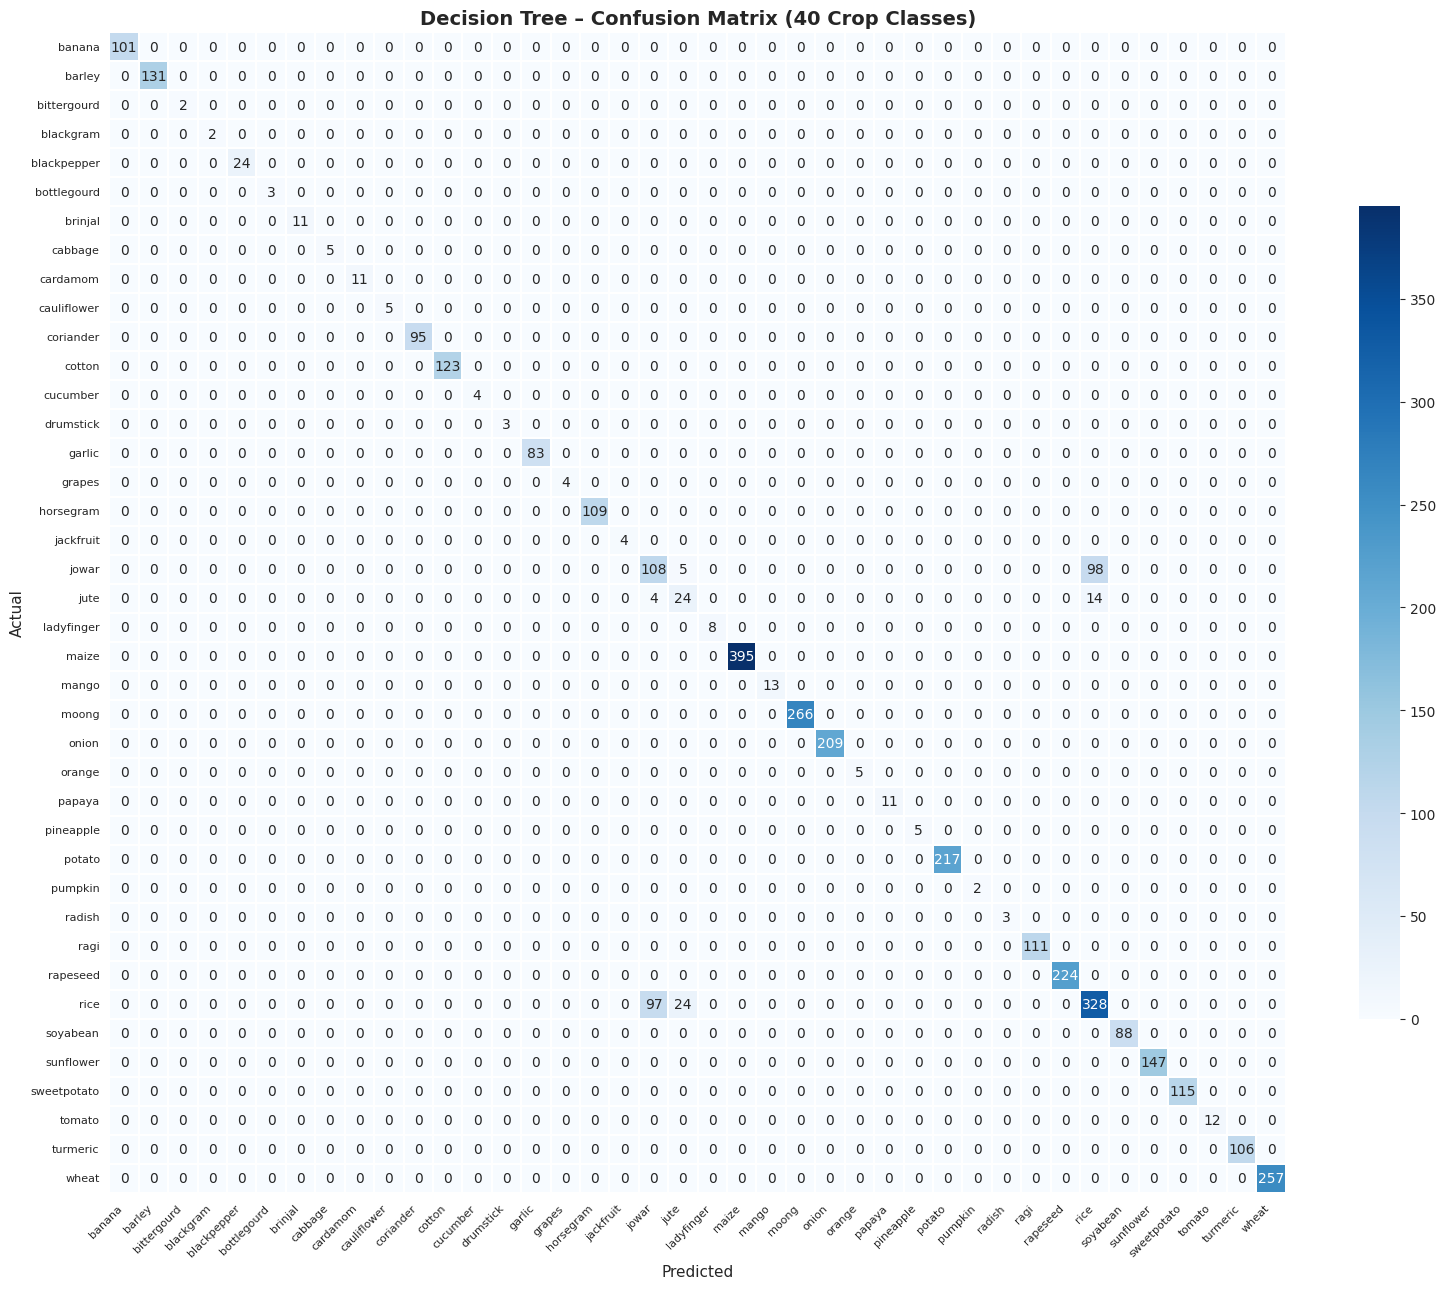

In [14]:
cm = confusion_matrix(y_test, y_preds[best_name])
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.3, cbar_kws={'shrink': 0.7})
ax.set_title(f'{best_name} – Confusion Matrix (40 Crop Classes)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### 6f. Random Forest Feature Importance

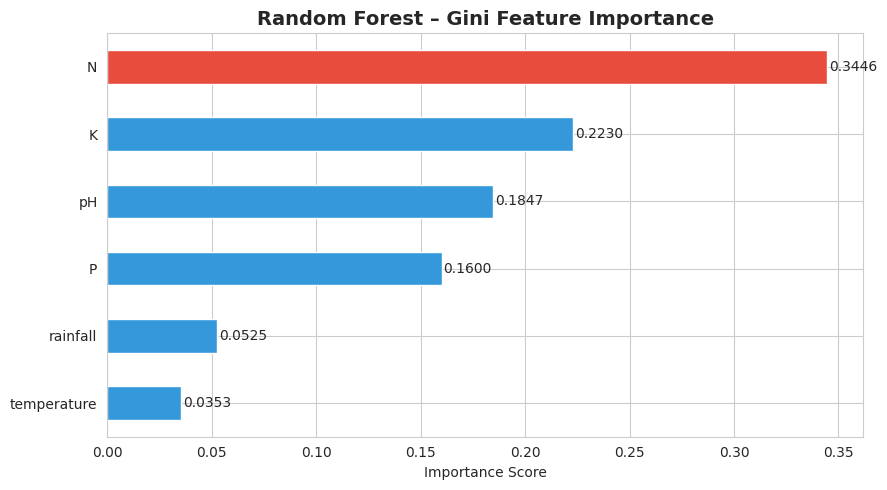

In [15]:
rf_model = trained_models['Random Forest']
fi = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
bar_cols = ['#E74C3C' if v == fi.max() else '#3498DB' for v in fi]
fi.plot.barh(ax=ax, color=bar_cols, edgecolor='white')
ax.set_title('Random Forest – Gini Feature Importance',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
for i, v in enumerate(fi):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 🔍 7. Explainable AI — SHAP
### SHapley Additive exPlanations  ·  Full Dataset

> **What is SHAP?**  
> Rooted in cooperative game theory, SHAP gives each feature a **Shapley value** —
> its *fair marginal contribution* to the prediction, averaged across all possible
> feature orderings.
>
> **Implementation used here — Tree Path Contributions:**  
> For each tree in the Random Forest we trace the decision path of every sample
> and accumulate the change in leaf-class probability at each split.  
> This runs in **O(n × depth × n_trees)** — fast enough for the full dataset.
>
> | SHAP Axiom | Meaning |
> |---|---|
> | Efficiency | Values sum to prediction − baseline |
> | Symmetry | Equal contributors → equal values |
> | Dummy | Unused features → SHAP = 0 |
> | Additivity | Values from sub-models combine correctly |

### 7a. SHAP – Tree Path Implementation (Full Dataset)

In [16]:
def compute_shap_tree_path(forest, X_explain):
    """
    SHAP via Random Forest leaf-path contributions.

    For each tree and each sample, we walk the decision path and
    record how the predicted class probability changes at each split.
    The feature that caused the split gets credited that change.
    Values are averaged across all trees.

    Parameters
    ----------
    forest    : fitted RandomForestClassifier
    X_explain : ndarray (n_samples, n_features) — full dataset to explain

    Returns
    -------
    contrib   : ndarray (n_samples, n_features) — signed SHAP contributions
    """
    n_samples, n_features = X_explain.shape
    contrib = np.zeros((n_samples, n_features))

    for tree in forest.estimators_:
        node_indicator = tree.decision_path(X_explain)  # sparse (n, n_nodes)
        leaf_ids       = tree.apply(X_explain)           # (n,)
        feature        = tree.tree_.feature              # (n_nodes,)
        value          = tree.tree_.value                # (n_nodes, 1, n_classes)
        nsw            = tree.tree_.weighted_n_node_samples  # (n_nodes,)

        for s in range(n_samples):
            node_ids  = node_indicator[s].indices
            pred_cls  = np.argmax(value[leaf_ids[s], 0])
            for i in range(len(node_ids) - 1):
                nid = node_ids[i]
                nxt = node_ids[i + 1]
                feat_idx = feature[nid]
                parent_prob = value[nid, 0, pred_cls] / nsw[nid]
                child_prob  = value[nxt, 0, pred_cls] / nsw[nxt]
                contrib[s, feat_idx] += child_prob - parent_prob

    contrib /= len(forest.estimators_)   # average over all trees
    return contrib


print('Computing SHAP on the FULL test set…')
print(f'Test set size: {X_test.shape[0]} samples × {X_test.shape[1]} features')

shap_matrix = compute_shap_tree_path(trained_models['Random Forest'], X_test)
mean_shap   = np.abs(shap_matrix).mean(axis=0)

print(f'\nSHAP matrix shape: {shap_matrix.shape}')
print('\nGlobal Mean |SHAP| per feature:')
for f, v in sorted(zip(FLABELS, mean_shap), key=lambda x: -x[1]):
    bar = '█' * int(v / mean_shap.max() * 30)
    print(f'  {f:<20s}  {bar:<30s}  {v:.5f}')

Computing SHAP on the FULL test set…
Test set size: 3616 samples × 6 features

SHAP matrix shape: (3616, 6)

Global Mean |SHAP| per feature:
  pH                    ██████████████████████████████  0.02325
  Rainfall              ███████                         0.00552
  Temperature           ███████                         0.00548
  Nitrogen (N)          ███                             0.00283
  Phosphorus (P)        █                               0.00143
  Potassium (K)         █                               0.00121


### 7b. SHAP Global Feature Importance Bar

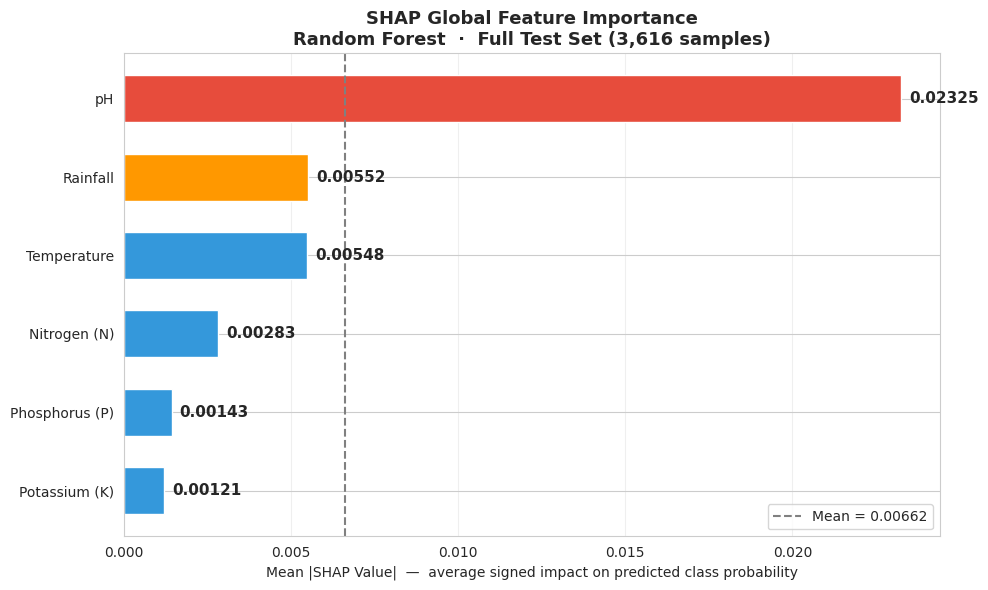

In [17]:
order = np.argsort(mean_shap)
fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [
    '#E74C3C' if i == order[-1] else
    '#FF9800' if i == order[-2] else '#3498DB'
    for i in order
]
bars = ax.barh([FLABELS[i] for i in order], mean_shap[order],
               color=bar_colors, edgecolor='white', height=0.6)
for bar, v in zip(bars, mean_shap[order]):
    ax.text(v + mean_shap.max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{v:.5f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|  —  average signed impact on predicted class probability',
              fontsize=10)
ax.set_title('SHAP Global Feature Importance\n'
             f'Random Forest  ·  Full Test Set ({X_test.shape[0]:,} samples)',
             fontsize=13, fontweight='bold')
ax.axvline(mean_shap.mean(), color='gray', ls='--', lw=1.5,
           label=f'Mean = {mean_shap.mean():.5f}')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 7c. SHAP Beeswarm Summary Plot — Full Dataset

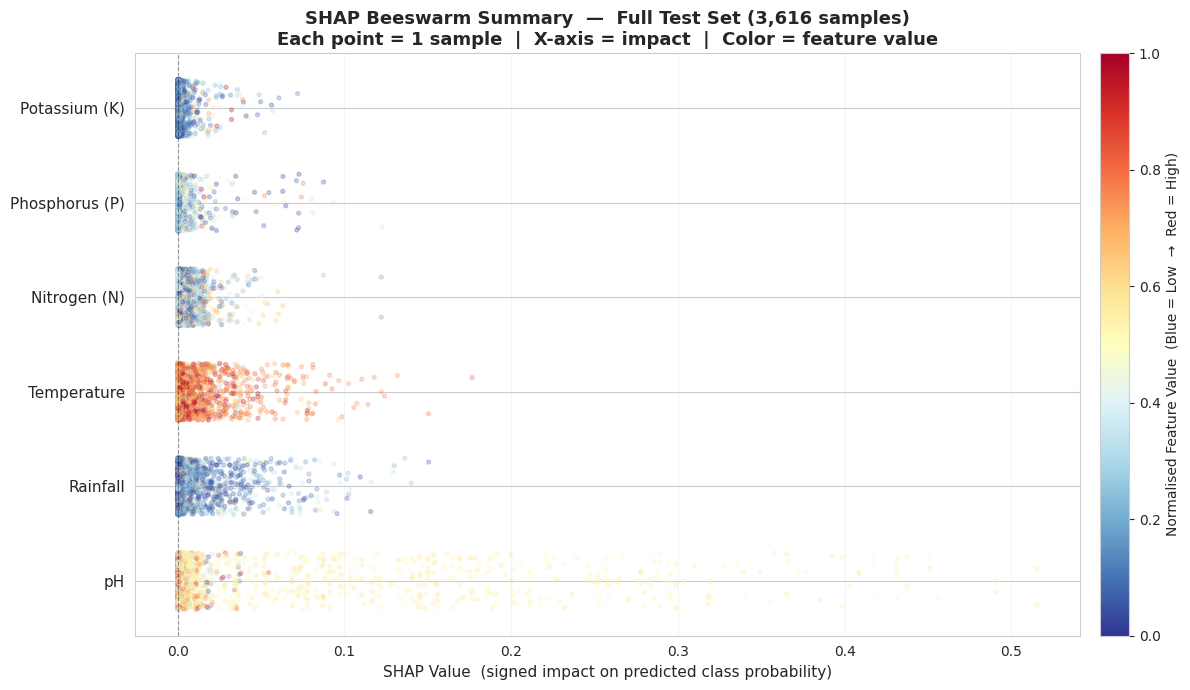

In [18]:
fig, ax = plt.subplots(figsize=(12, 7))
order_desc = np.argsort(mean_shap)[::-1]

# Plot all test samples — no subsampling
for pos, fi_idx in enumerate(order_desc):
    sv   = shap_matrix[:, fi_idx]
    fv   = X_test[:, fi_idx]
    fv_n = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
    jitter = np.random.default_rng(fi_idx).uniform(-0.3, 0.3, len(sv))
    ax.scatter(sv, np.full(len(sv), pos) + jitter,
               c=fv_n, cmap='RdYlBu_r',
               alpha=0.25, s=8, vmin=0, vmax=1,
               rasterized=True)          # rasterised for file size

sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=plt.Normalize(0, 1))
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.03)
cb.set_label('Normalised Feature Value  (Blue = Low  →  Red = High)', fontsize=10)
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels([FLABELS[i] for i in order_desc], fontsize=11)
ax.set_xlabel('SHAP Value  (signed impact on predicted class probability)', fontsize=11)
ax.set_title(
    f'SHAP Beeswarm Summary  —  Full Test Set ({X_test.shape[0]:,} samples)\n'
    'Each point = 1 sample  |  X-axis = impact  |  Color = feature value',
    fontsize=13, fontweight='bold'
)
ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.4)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

### 7d. SHAP Violin Plot — Distribution per Feature

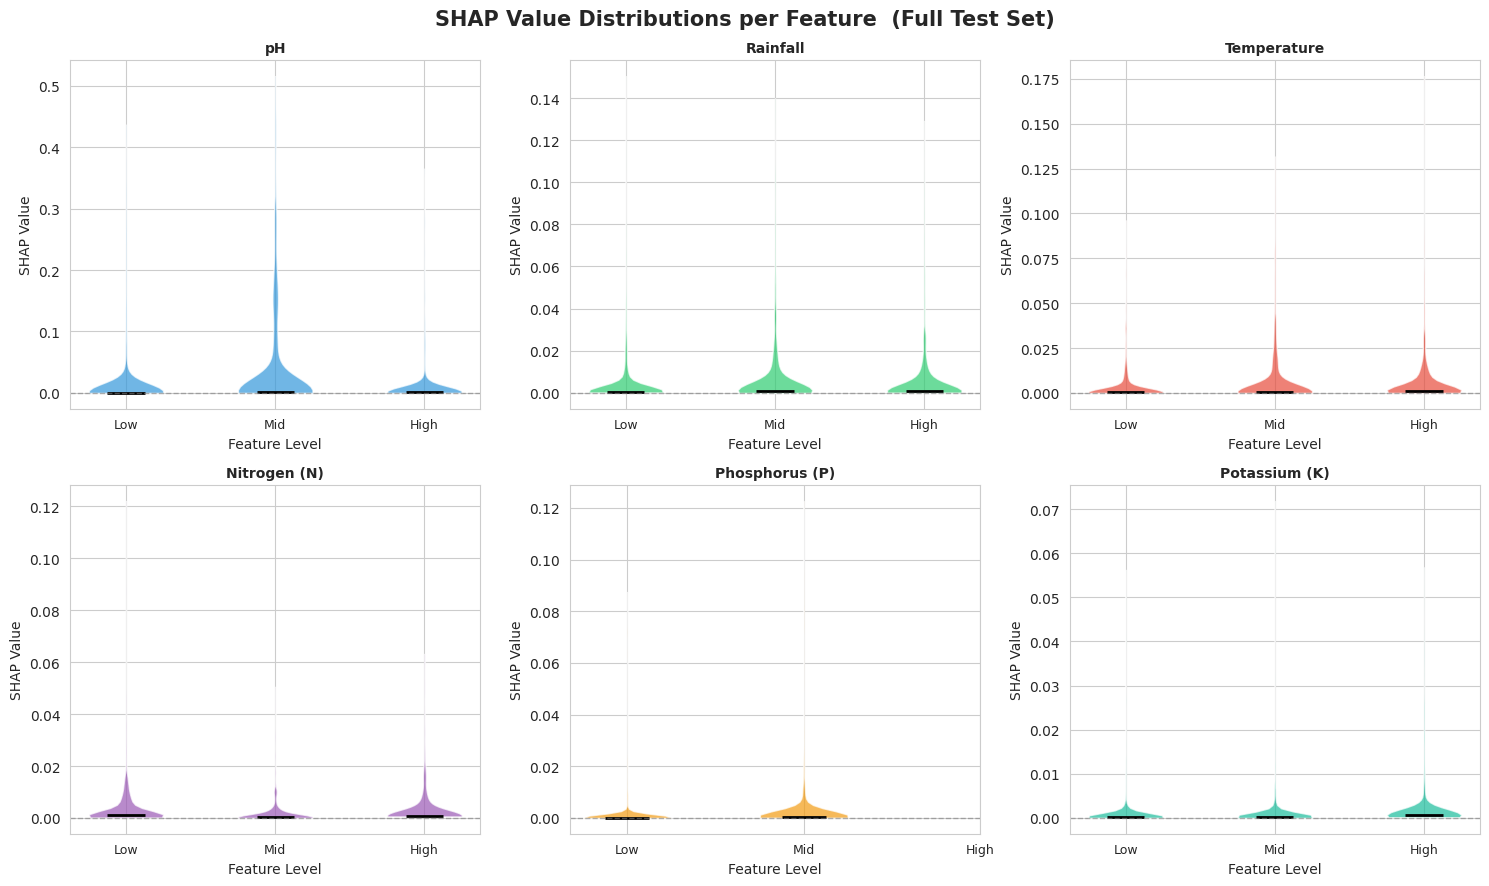

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('SHAP Value Distributions per Feature  (Full Test Set)',
             fontsize=15, fontweight='bold')
for ax, fi_idx, lbl, col in zip(axes.flatten(),
                                 np.argsort(mean_shap)[::-1],
                                 [FLABELS[i] for i in np.argsort(mean_shap)[::-1]],
                                 COLORS):
    sv   = shap_matrix[:, fi_idx]
    fv   = X_test[:, fi_idx]
    # bin feature into low / mid / high
    q33, q67 = np.percentile(fv, [33, 67])
    grp = np.where(fv <= q33, 'Low', np.where(fv <= q67, 'Mid', 'High'))
    grp_order = ['Low','Mid','High']
    data_by_grp = [sv[grp == g] for g in grp_order if np.sum(grp == g) > 0]

    parts = ax.violinplot(
        data_by_grp,
        positions=range(len(data_by_grp)),
        showmedians=True,
        showextrema=False
    )
    for pc in parts['bodies']:
        pc.set_facecolor(col); pc.set_alpha(0.7)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    ax.set_xticks([0,1,2]); ax.set_xticklabels(grp_order, fontsize=9)
    ax.set_title(lbl, fontweight='bold', fontsize=10)
    ax.set_ylabel('SHAP Value'); ax.set_xlabel('Feature Level')
    ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.6)
plt.tight_layout()
plt.show()

### 7e. SHAP Force Plots — 6 Individual Predictions

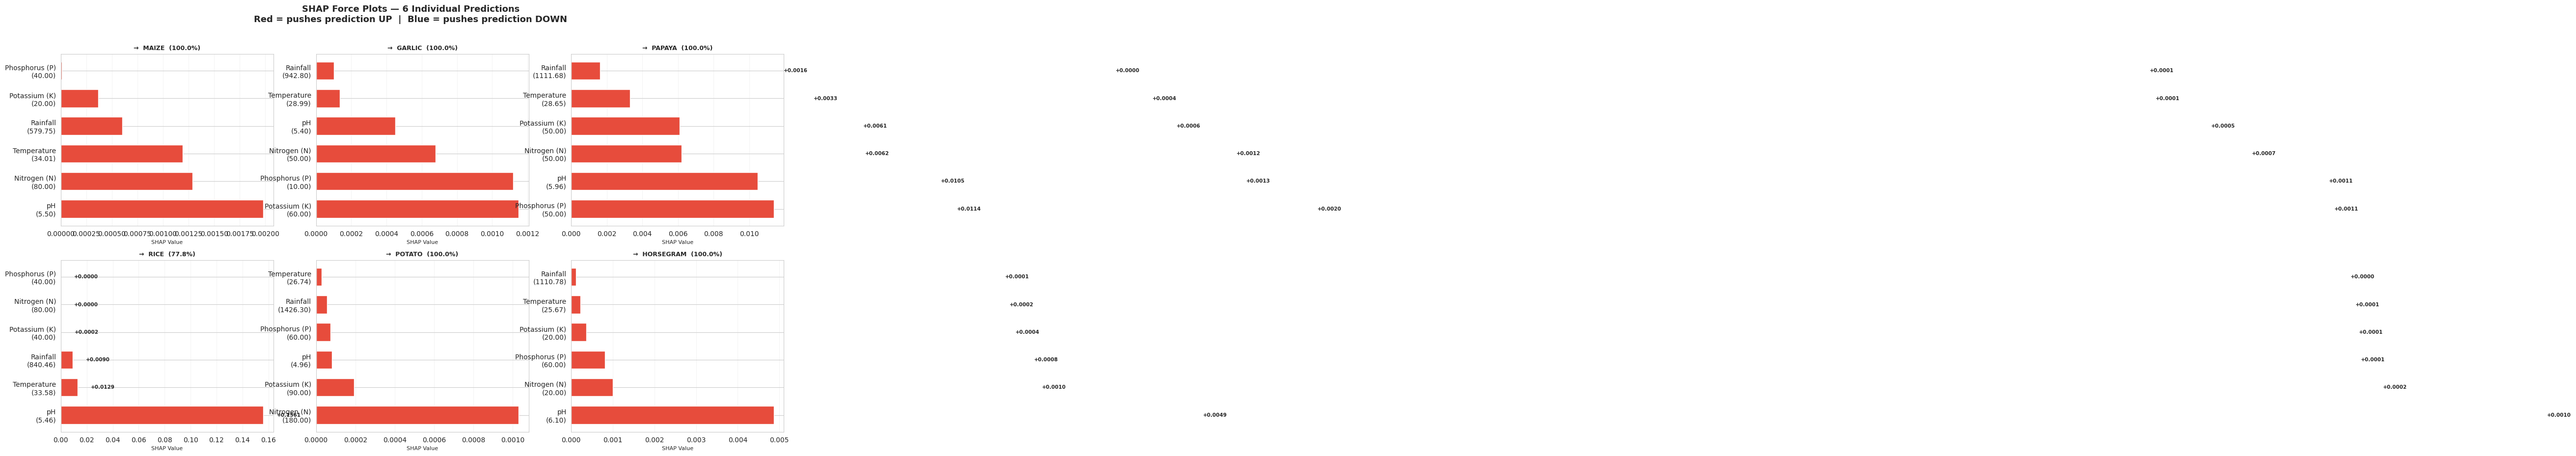

In [20]:
def draw_shap_force(ax, shap_row, feat_vals, feat_labels, crop_name, pred_prob):
    """Waterfall-style force plot for one prediction."""
    idx_s = np.argsort(np.abs(shap_row))[::-1]
    names = [f'{feat_labels[i]}\n({feat_vals[i]:.2f})' for i in idx_s]
    vals  = [shap_row[i] for i in idx_s]
    cols  = ['#E74C3C' if v >= 0 else '#3498DB' for v in vals]
    bars  = ax.barh(names, vals, color=cols, edgecolor='white', height=0.65)
    ax.axvline(0, color='black', lw=1.2, alpha=0.7)
    ax.set_title(f'→  {crop_name.upper()}  ({pred_prob:.1%})',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('SHAP Value', fontsize=8)
    for bar, v in zip(bars, vals):
        offset = shap_matrix.max() * 0.02
        ax.text(v + (offset if v >= 0 else -offset),
                bar.get_y() + bar.get_height()/2,
                f'{v:+.4f}', va='center', fontsize=7.5,
                ha='left' if v >= 0 else 'right', fontweight='bold')
    ax.grid(axis='x', alpha=0.2)

# Pick 6 diverse indices spread evenly across test set
n_force   = 6
force_idx = np.linspace(0, len(X_test)-1, n_force, dtype=int)
rf_model  = trained_models['Random Forest']

fig, axes = plt.subplots(2, 3, figsize=(19, 10))
fig.suptitle('SHAP Force Plots — 6 Individual Predictions\n'
             'Red = pushes prediction UP  |  Blue = pushes prediction DOWN',
             fontsize=13, fontweight='bold')
for ax, idx in zip(axes.flatten(), force_idx):
    pc   = rf_model.predict(X_test[idx:idx+1])[0]
    prob = rf_model.predict_proba(X_test[idx:idx+1])[0][pc]
    draw_shap_force(ax, shap_matrix[idx], X_test[idx],
                    FLABELS, le.classes_[pc], prob)
plt.tight_layout()
plt.show()

### 7f. SHAP Dependence Plots — Top 2 Features

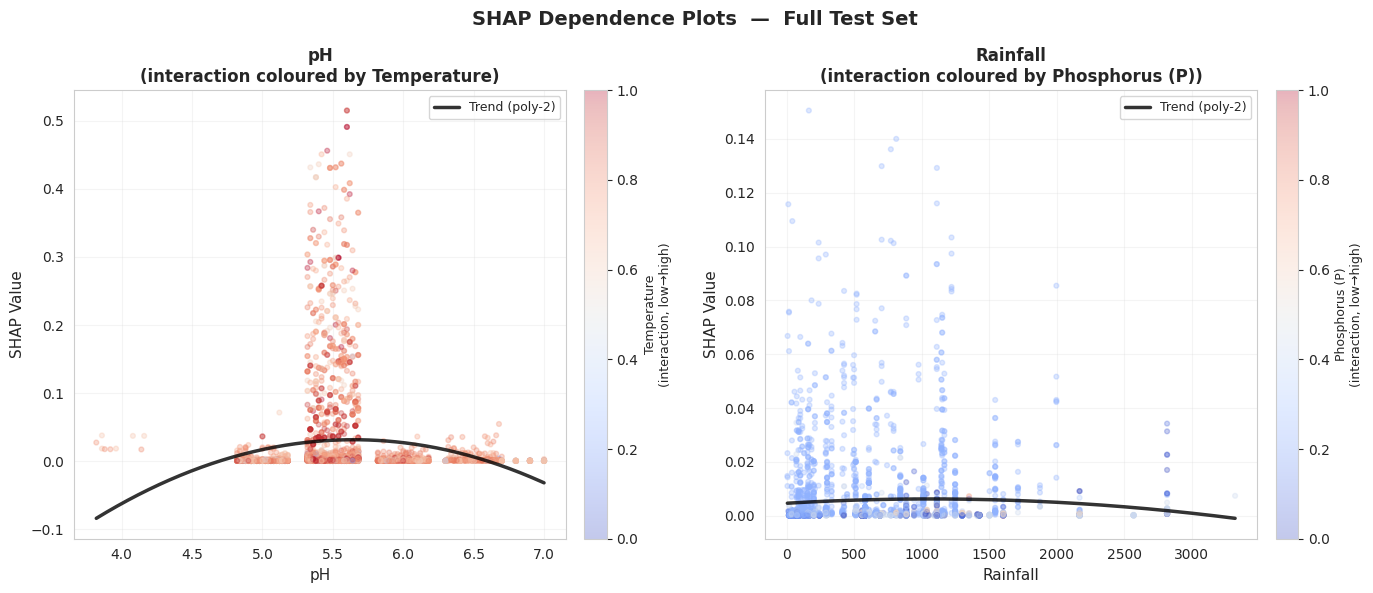

In [21]:
top2_idx = np.argsort(mean_shap)[::-1][:2]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('SHAP Dependence Plots  —  Full Test Set',
             fontsize=14, fontweight='bold')

for ax, fi_idx in zip(axes, top2_idx):
    fv, sv = X_test[:, fi_idx], shap_matrix[:, fi_idx]
    # Auto-detect interaction feature
    resid  = sv - np.polyval(np.polyfit(fv, sv, 1), fv)
    others = [k for k in range(len(FEATURES)) if k != fi_idx]
    int_i  = others[int(np.argmax([
        abs(np.corrcoef(X_test[:, k], resid)[0, 1]) for k in others
    ]))]
    iv   = X_test[:, int_i]
    iv_n = (iv - iv.min()) / (iv.max() - iv.min() + 1e-9)

    sc  = ax.scatter(fv, sv, c=iv_n, cmap='coolwarm',
                     alpha=0.3, s=12, vmin=0, vmax=1, rasterized=True)
    xl  = np.linspace(fv.min(), fv.max(), 300)
    ax.plot(xl, np.poly1d(np.polyfit(fv, sv, 2))(xl),
            'k-', lw=2.5, alpha=0.8, label='Trend (poly-2)')
    cb = fig.colorbar(sc, ax=ax, pad=0.03)
    cb.set_label(f'{FLABELS[int_i]}\n(interaction, low→high)', fontsize=9)
    ax.set_xlabel(FLABELS[fi_idx], fontsize=11)
    ax.set_ylabel('SHAP Value', fontsize=11)
    ax.set_title(
        f'{FLABELS[fi_idx]}\n'
        f'(interaction coloured by {FLABELS[int_i]})',
        fontweight='bold'
    )
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 7g. SHAP Per-Crop Heatmap — All 40 Crops

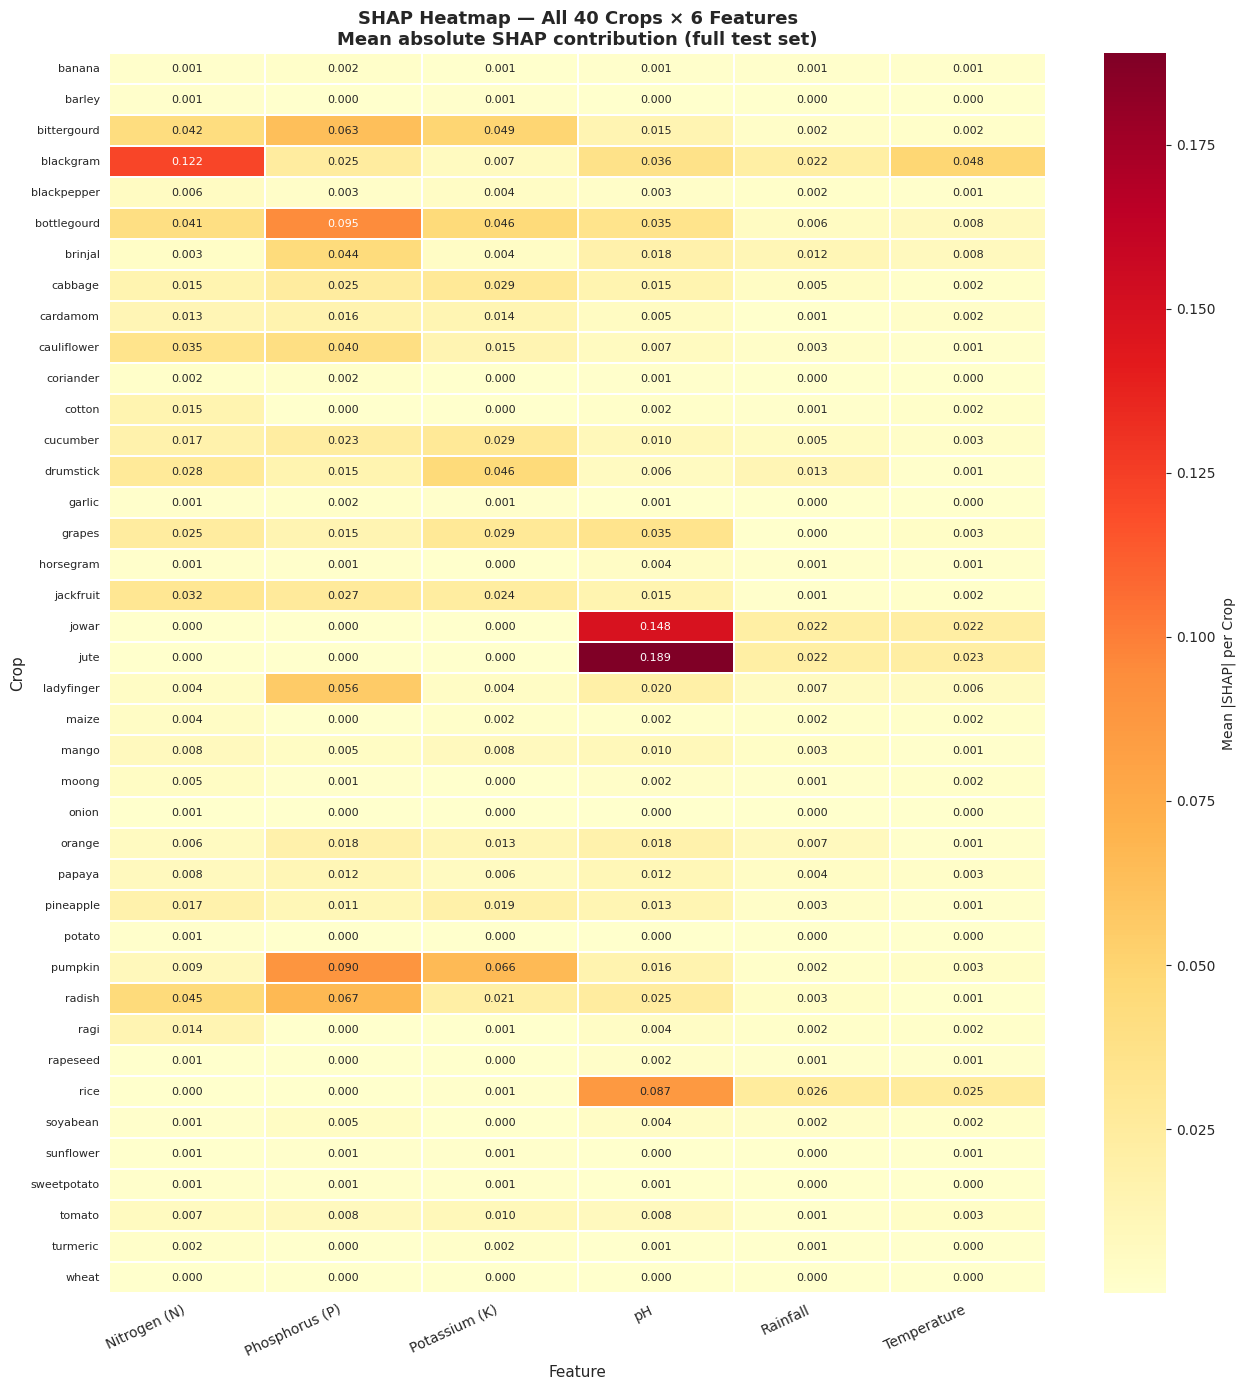

In [22]:
crop_labels_test = le.classes_[y_test]
all_crops        = le.classes_   # all 40

# Compute mean |SHAP| for every crop present in test set
shap_hm = np.zeros((len(all_crops), len(FEATURES)))
for i, crop in enumerate(all_crops):
    mask = crop_labels_test == crop
    if mask.sum() > 0:
        shap_hm[i] = np.abs(shap_matrix[mask]).mean(axis=0)

fig, ax = plt.subplots(figsize=(13, 14))
sns.heatmap(shap_hm,
            annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=FLABELS,
            yticklabels=all_crops,
            ax=ax, linewidths=0.3,
            annot_kws={'size': 8},
            cbar_kws={'label': 'Mean |SHAP| per Crop'})
ax.set_title('SHAP Heatmap — All 40 Crops × 6 Features\n'
             'Mean absolute SHAP contribution (full test set)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Crop',    fontsize=11)
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

### 7h. SHAP Waterfall (Cumulative) — Top 10 Most Explained Samples

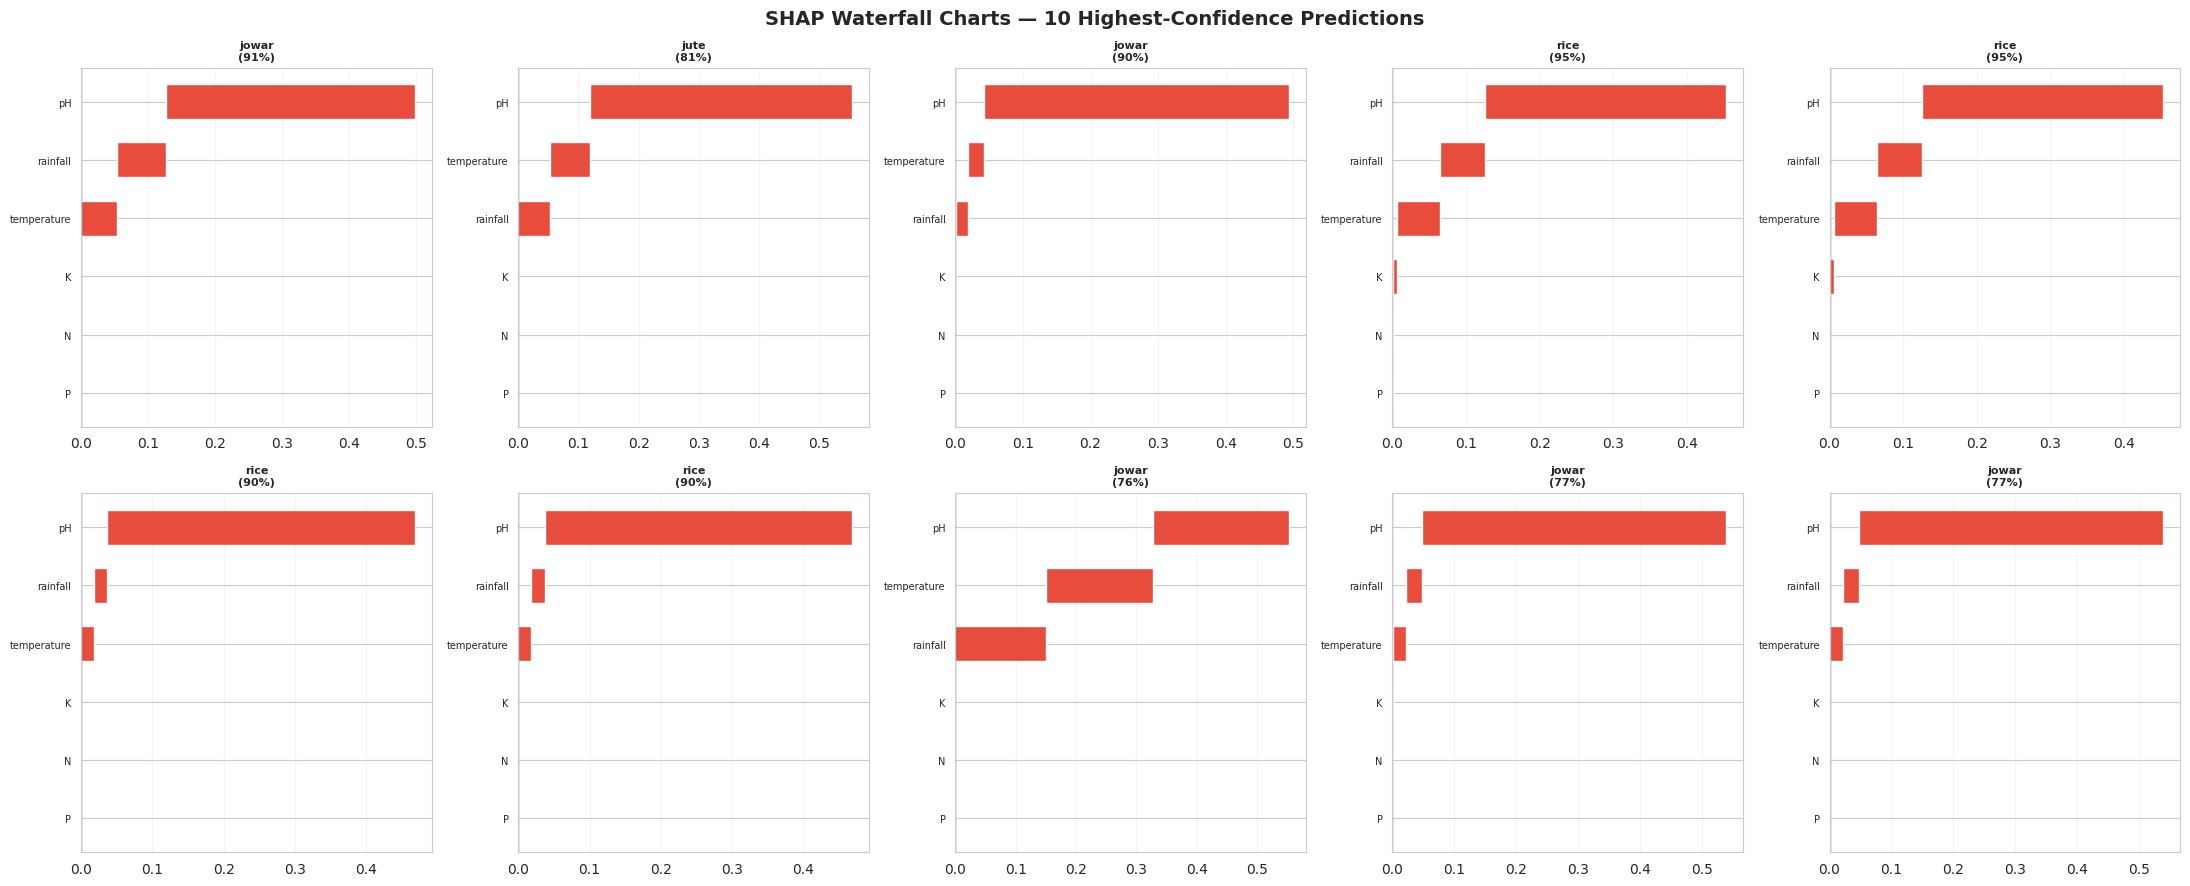

In [23]:
# Samples where the model is most confident AND SHAP values are largest
rf_probs     = trained_models['Random Forest'].predict_proba(X_test)
max_probs    = rf_probs.max(axis=1)
total_shap   = np.abs(shap_matrix).sum(axis=1)
score        = max_probs * total_shap      # high conf + high SHAP
top10_idx    = np.argsort(score)[::-1][:10]

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle('SHAP Waterfall Charts — 10 Highest-Confidence Predictions',
             fontsize=14, fontweight='bold')

for ax, idx in zip(axes.flatten(), top10_idx):
    pc    = trained_models['Random Forest'].predict(X_test[idx:idx+1])[0]
    prob  = rf_probs[idx, pc]
    sv    = shap_matrix[idx]
    order = np.argsort(sv)   # low → high for waterfall
    cumulative = np.cumsum(sv[order])
    starts     = np.concatenate([[0], cumulative[:-1]])
    cols       = ['#E74C3C' if v >= 0 else '#3498DB' for v in sv[order]]
    ax.barh(range(len(FEATURES)), sv[order],
            left=starts, color=cols, edgecolor='white', height=0.6)
    ax.set_yticks(range(len(FEATURES)))
    ax.set_yticklabels([FEATURES[i] for i in order], fontsize=7)
    ax.set_title(f'{le.classes_[pc]}\n({prob:.0%})',
                 fontsize=8, fontweight='bold')
    ax.axvline(0, color='black', lw=1, alpha=0.5)
    ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

---
## 🔬 8. Explainable AI — LIME
### Local Interpretable Model-Agnostic Explanations

> **What is LIME?**  
> LIME explains *one prediction at a time* by fitting a simple linear surrogate model
> that approximates the black-box *locally* around the input.
>
> **Algorithm:**
> ```
> For each sample x:
>   1. Perturb  — add Gaussian noise to generate neighbourhood samples
>   2. Query    — get black-box predictions on all perturbed samples
>   3. Weight   — assign proximity score via Gaussian kernel
>   4. Fit      — weighted Ridge regression on perturbations
>   5. Read     — regression coefficients = local feature importance
> ```
>
> **Full-dataset strategy:**  
> We run the batch LIME loop over every sample in the test set and accumulate
> all coefficient matrices for both local and global analysis.

### 8a. LIME — Batch Implementation (Full Test Set)

In [24]:
def compute_lime_batch(model, X_explain, X_train_bg,
                       n_samples=500, kernel_width=None, seed=42):
    """
    Batch LIME over the entire X_explain set.

    For each sample x in X_explain:
      1. Generate n_samples Gaussian perturbations around x
      2. Query the black-box for predicted-class probabilities
      3. Weight perturbations by Gaussian proximity kernel
      4. Fit weighted Ridge regression → local surrogate

    Parameters
    ----------
    model        : fitted sklearn classifier with predict_proba()
    X_explain    : ndarray (n, p) — full set to explain
    X_train_bg   : ndarray — used for feature scale & value clipping
    n_samples    : perturbations per sample  (500 is a good balance)
    kernel_width : Gaussian bandwidth (auto = sqrt(p)*0.3)
    seed         : reproducibility

    Returns
    -------
    coef_matrix  : ndarray (n, p) — local LIME coefficients per sample
    r2_scores    : ndarray (n,)   — surrogate quality per sample
    pred_classes : ndarray (n,)   — predicted class index per sample
    pred_probs   : ndarray (n,)   — prediction confidence per sample
    """
    rng   = np.random.default_rng(seed)
    n, p  = X_explain.shape
    std   = X_train_bg.std(axis=0) + 1e-8
    lo    = X_train_bg.min(axis=0)
    hi    = X_train_bg.max(axis=0)
    if kernel_width is None:
        kernel_width = np.sqrt(p) * 0.3

    coef_matrix  = np.zeros((n, p))
    r2_scores    = np.zeros(n)
    pred_classes = np.zeros(n, dtype=int)
    pred_probs   = np.zeros(n)

    for i, x in enumerate(X_explain):
        # 1. Perturb
        noise  = rng.normal(0, 1, (n_samples, p))
        X_pert = np.clip(x + noise * std * 0.4, lo, hi)

        # 2. Black-box query
        pc    = model.predict(x.reshape(1, -1))[0]
        probs = model.predict_proba(X_pert)[:, pc]

        # 3. Proximity weights
        dist  = np.sqrt(((X_pert - x)**2 / std**2).sum(axis=1))
        w     = np.exp(-(dist**2) / (2 * kernel_width**2))

        # 4. Weighted Ridge regression
        mu    = X_pert.mean(0); sigma = X_pert.std(0) + 1e-8
        X_n   = (X_pert - mu) / sigma
        reg   = Ridge(alpha=1.0)
        reg.fit(X_n, probs, sample_weight=w)

        # Surrogate quality (weighted R²)
        p_hat  = reg.predict(X_n)
        ss_res = ((probs - p_hat)**2 * w).sum()
        ss_tot = ((probs - np.average(probs, weights=w))**2 * w).sum()

        coef_matrix[i]  = reg.coef_
        r2_scores[i]    = 1 - ss_res / (ss_tot + 1e-12)
        pred_classes[i] = pc
        pred_probs[i]   = model.predict_proba(x.reshape(1,-1))[0][pc]

    return coef_matrix, r2_scores, pred_classes, pred_probs


print('Computing LIME on the FULL test set…')
print(f'Test set size : {X_test.shape[0]} samples × {X_test.shape[1]} features')
print('(n_samples=500 perturbations per test sample)')

lime_coefs, lime_r2, lime_pred_cls, lime_pred_prob = compute_lime_batch(
    trained_models['Random Forest'], X_test, X_train, n_samples=500
)

mean_lime = np.abs(lime_coefs).mean(axis=0)
print(f'\nLIME coefficient matrix shape : {lime_coefs.shape}')
print(f'Mean surrogate R²             : {lime_r2.mean():.4f}')
print('\nGlobal Mean |LIME Coef| per feature:')
for f, v in sorted(zip(FLABELS, mean_lime), key=lambda x: -x[1]):
    bar = '█' * int(v / mean_lime.max() * 30)
    print(f'  {f:<20s}  {bar:<30s}  {v:.4f}')

Computing LIME on the FULL test set…
Test set size : 3616 samples × 6 features
(n_samples=500 perturbations per test sample)

LIME coefficient matrix shape : (3616, 6)
Mean surrogate R²             : 0.3278

Global Mean |LIME Coef| per feature:
  Potassium (K)         ██████████████████████████████  0.0919
  Nitrogen (N)          ███████████████████████████     0.0850
  pH                    █████████████████               0.0539
  Phosphorus (P)        ████████                        0.0257
  Rainfall              ████                            0.0128
  Temperature           ███                             0.0113


### 8b. LIME Surrogate Quality Distribution

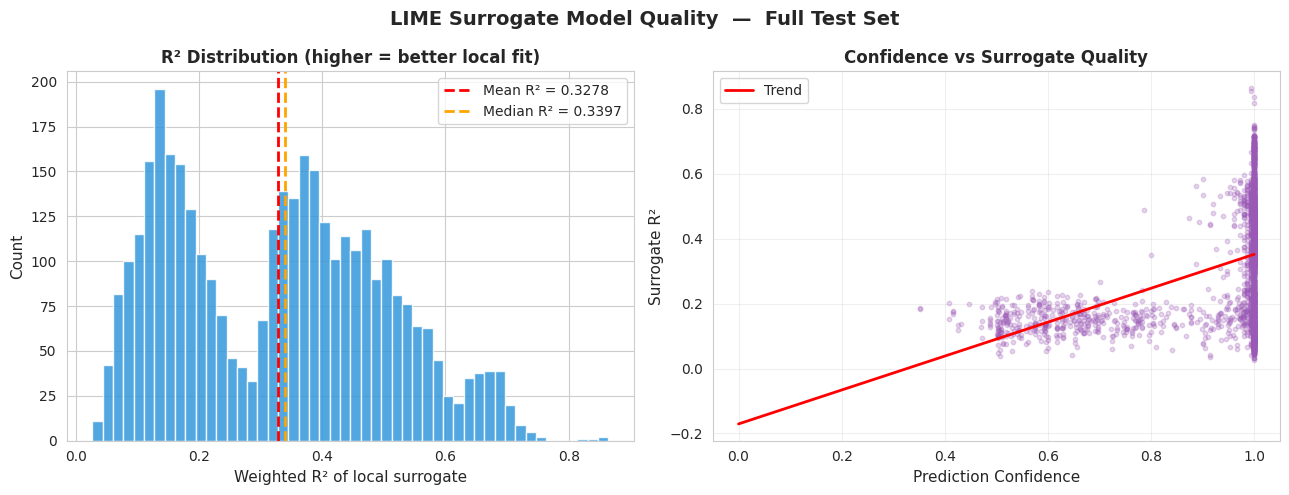

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('LIME Surrogate Model Quality  —  Full Test Set',
             fontsize=14, fontweight='bold')

axes[0].hist(lime_r2, bins=50, color='#3498DB', edgecolor='white', alpha=0.85)
axes[0].axvline(lime_r2.mean(), color='red', ls='--', lw=2,
                label=f'Mean R² = {lime_r2.mean():.4f}')
axes[0].axvline(np.median(lime_r2), color='orange', ls='--', lw=2,
                label=f'Median R² = {np.median(lime_r2):.4f}')
axes[0].set_xlabel('Weighted R² of local surrogate', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('R² Distribution (higher = better local fit)', fontweight='bold')
axes[0].legend(fontsize=10)

axes[1].scatter(lime_pred_prob, lime_r2, alpha=0.25, s=10,
               color='#9B59B6', rasterized=True)
axes[1].set_xlabel('Prediction Confidence', fontsize=11)
axes[1].set_ylabel('Surrogate R²', fontsize=11)
axes[1].set_title('Confidence vs Surrogate Quality', fontweight='bold')
z = np.polyfit(lime_pred_prob, lime_r2, 1)
xl = np.linspace(0, 1, 200)
axes[1].plot(xl, np.poly1d(z)(xl), 'r-', lw=2, label='Trend')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 8c. LIME Global Feature Importance — Full Test Set

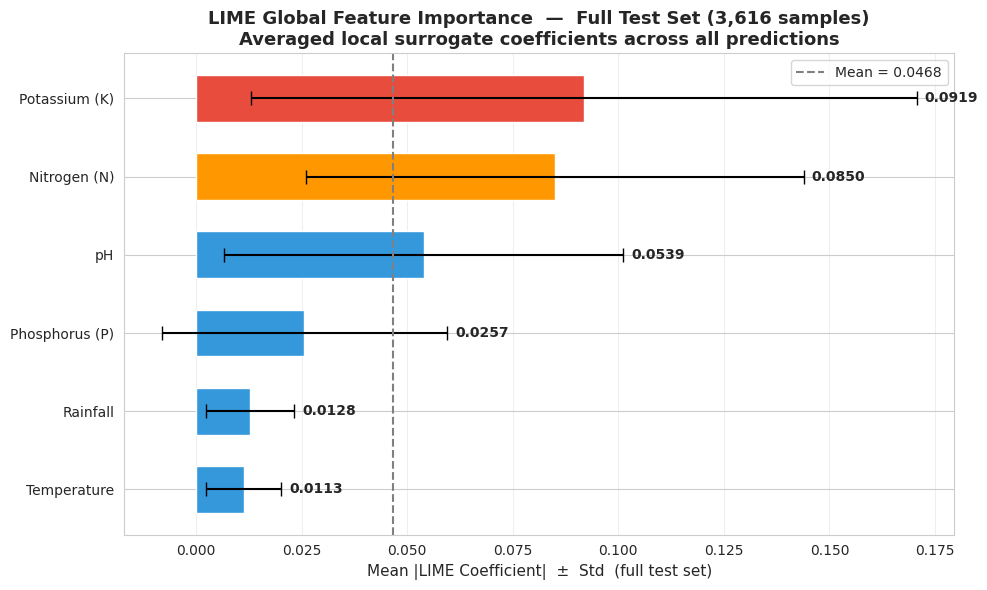

In [26]:
std_lime  = np.abs(lime_coefs).std(axis=0)
order     = np.argsort(mean_lime)

fig, ax = plt.subplots(figsize=(10, 6))
bar_cols = [
    '#E74C3C' if i == order[-1] else
    '#FF9800' if i == order[-2] else '#3498DB'
    for i in order
]
ax.barh([FLABELS[i] for i in order], mean_lime[order],
        xerr=std_lime[order], color=bar_cols, edgecolor='white',
        height=0.6, capsize=5)
for i, (v, s) in enumerate(zip(mean_lime[order], std_lime[order])):
    ax.text(v + s + mean_lime.max()*0.02, i,
            f'{v:.4f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Mean |LIME Coefficient|  ±  Std  (full test set)', fontsize=11)
ax.set_title(
    f'LIME Global Feature Importance  —  Full Test Set ({X_test.shape[0]:,} samples)\n'
    'Averaged local surrogate coefficients across all predictions',
    fontsize=13, fontweight='bold'
)
ax.axvline(mean_lime.mean(), color='gray', ls='--', lw=1.5,
           label=f'Mean = {mean_lime.mean():.4f}')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 8d. LIME Individual Explanations — 6 Samples

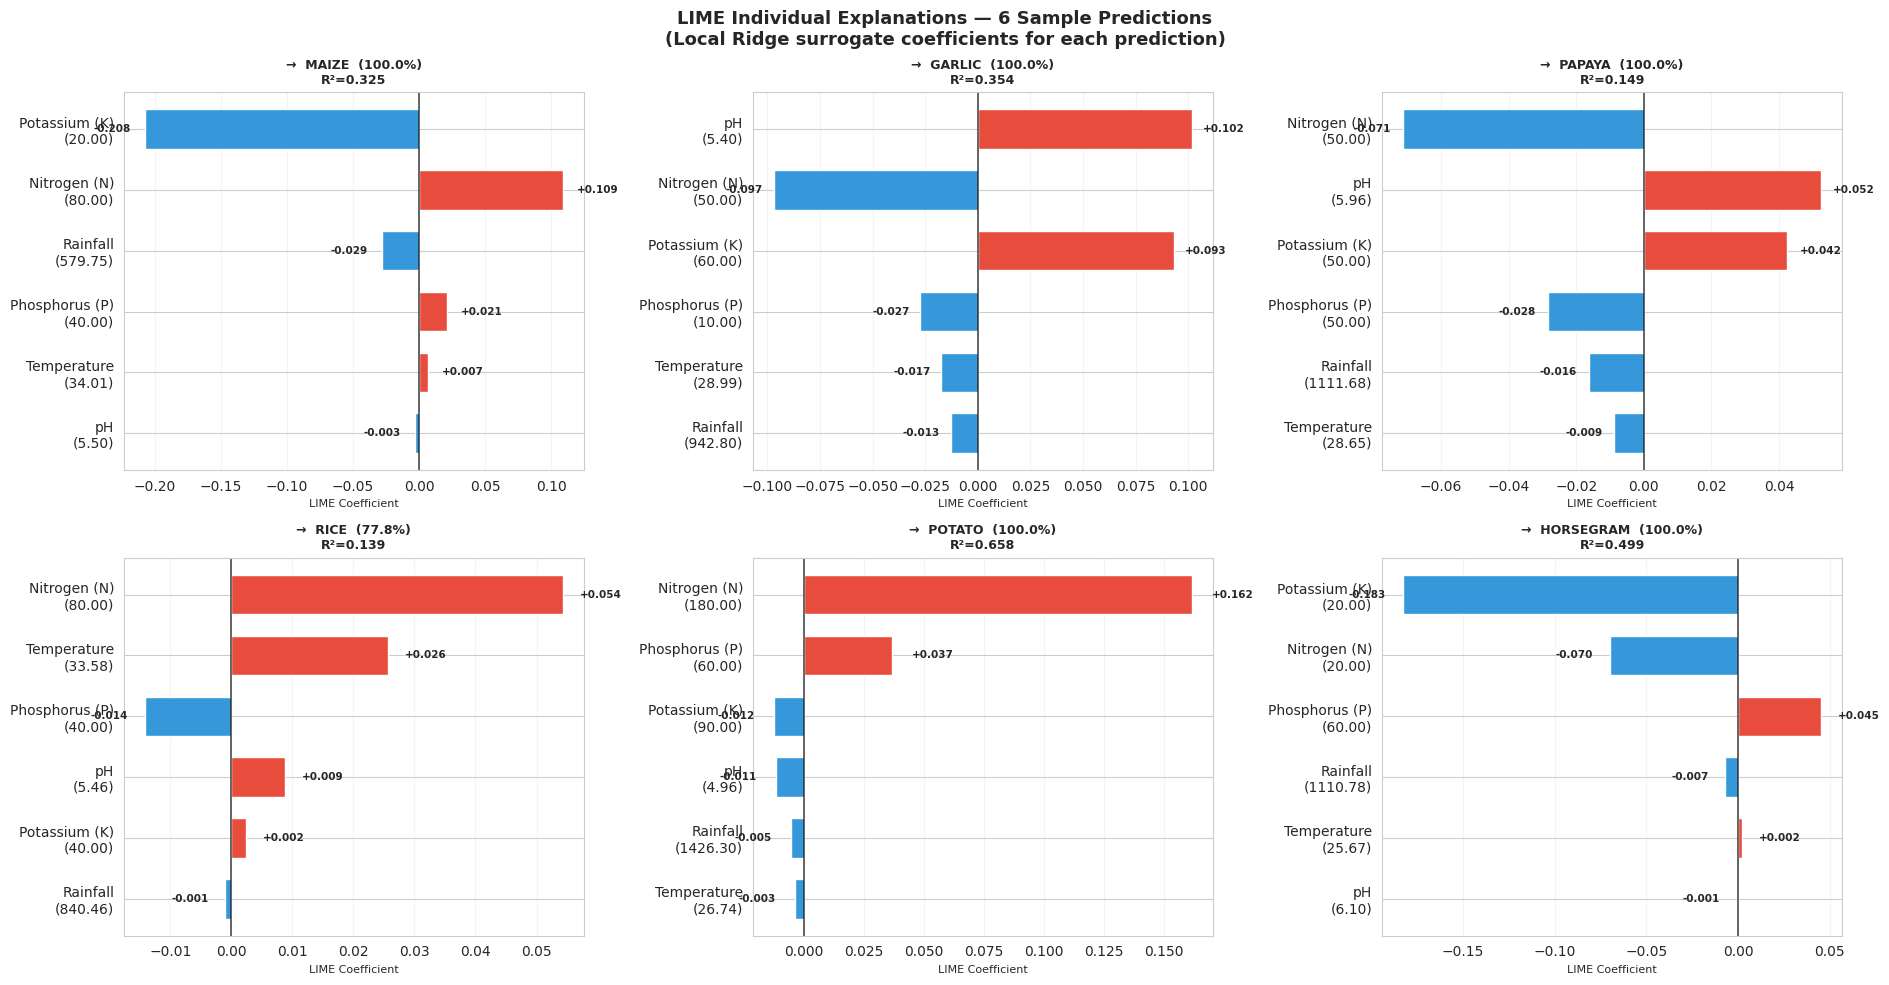

In [27]:
def draw_lime_bar(ax, coef, feat_vals, feat_labels, crop_name, pred_prob, r2):
    """Horizontal bar chart of LIME coefficients for one prediction."""
    order = np.argsort(np.abs(coef))
    names = [f'{feat_labels[i]}\n({feat_vals[i]:.2f})' for i in order]
    vals  = coef[order]
    cols  = ['#E74C3C' if v > 0 else '#3498DB' for v in vals]
    bars  = ax.barh(names, vals, color=cols, edgecolor='white', height=0.65)
    ax.axvline(0, color='black', lw=1.2, alpha=0.7)
    ax.set_title(f'→  {crop_name.upper()}  ({pred_prob:.1%})\nR²={r2:.3f}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('LIME Coefficient', fontsize=8)
    for bar, v in zip(bars, vals):
        offset = np.abs(vals).max() * 0.05
        ax.text(v + (offset if v >= 0 else -offset),
                bar.get_y() + bar.get_height()/2,
                f'{v:+.3f}', va='center', fontsize=7.5,
                ha='left' if v >= 0 else 'right', fontweight='bold')
    ax.grid(axis='x', alpha=0.2)

# Pick 6 samples spread across the test set
force_idx = np.linspace(0, len(X_test)-1, 6, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(19, 10))
fig.suptitle('LIME Individual Explanations — 6 Sample Predictions\n'
             '(Local Ridge surrogate coefficients for each prediction)',
             fontsize=13, fontweight='bold')
for ax, idx in zip(axes.flatten(), force_idx):
    crop = le.classes_[lime_pred_cls[idx]]
    draw_lime_bar(ax, lime_coefs[idx], X_test[idx],
                  FLABELS, crop, lime_pred_prob[idx], lime_r2[idx])
plt.tight_layout()
plt.show()

### 8e. LIME Per-Crop Coefficient Heatmap — All 40 Crops

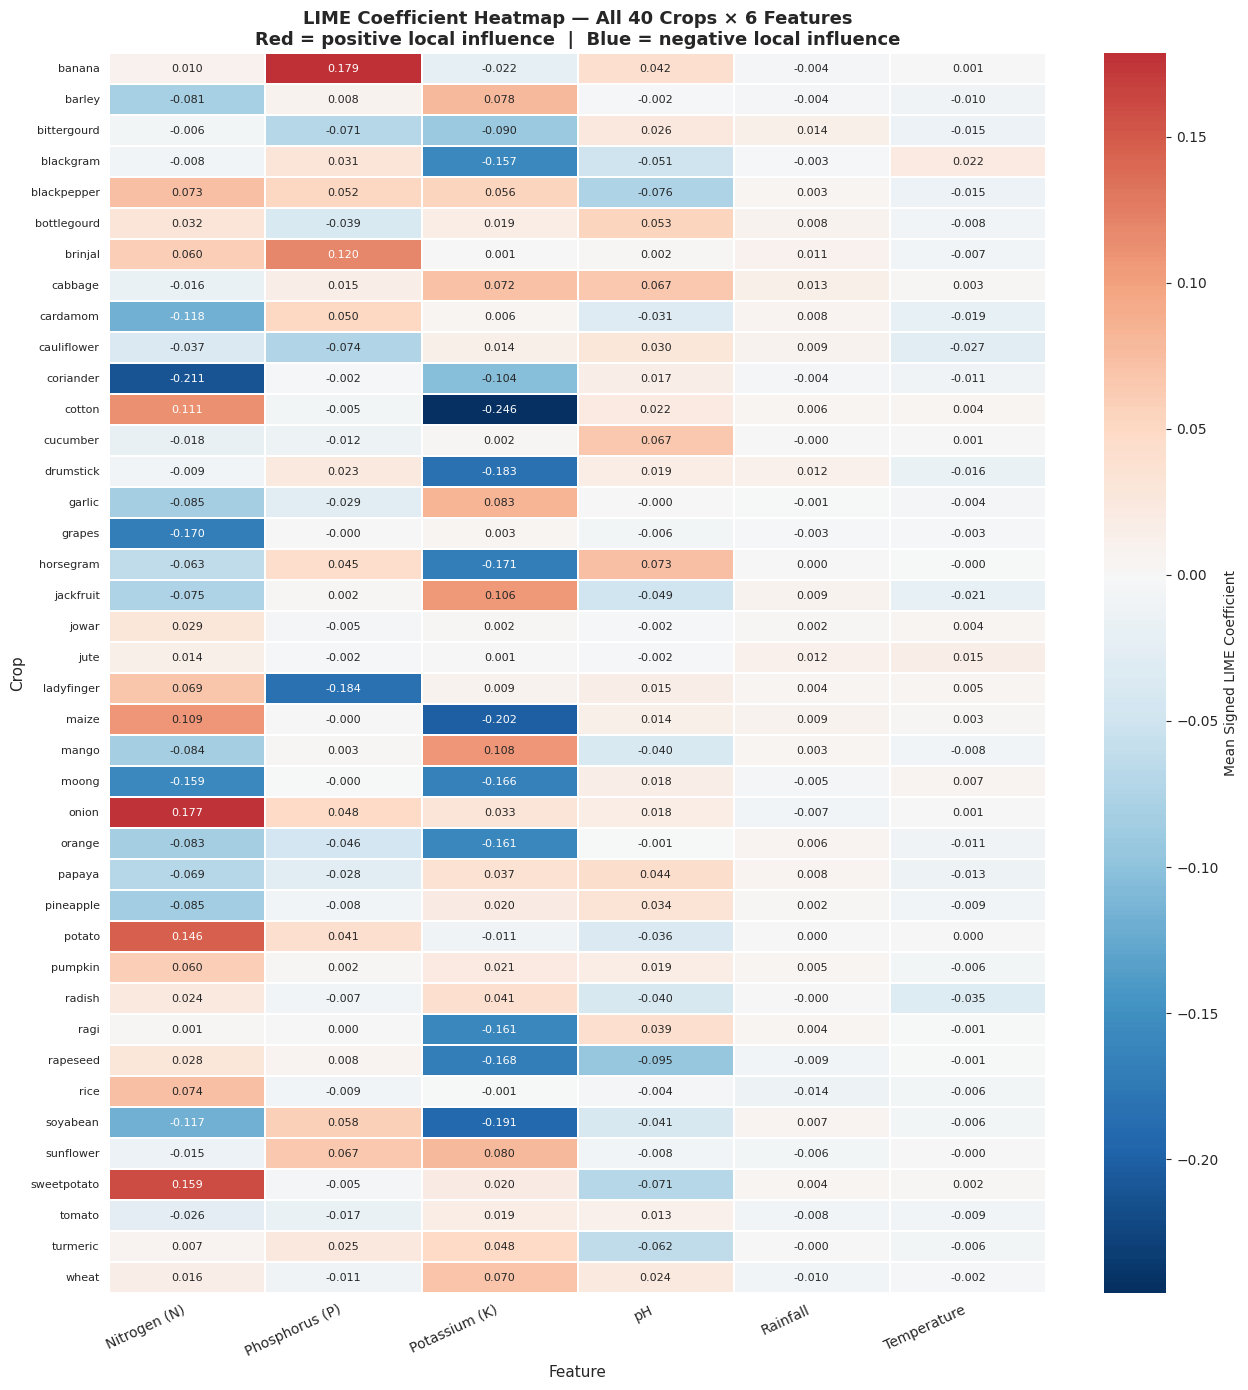

In [28]:
# Compute mean signed LIME coefficient per crop
lime_hm     = np.zeros((len(le.classes_), len(FEATURES)))
sample_crops = le.classes_[lime_pred_cls]

for i, crop in enumerate(le.classes_):
    mask = sample_crops == crop
    if mask.sum() > 0:
        lime_hm[i] = lime_coefs[mask].mean(axis=0)  # signed mean

fig, ax = plt.subplots(figsize=(13, 14))
sns.heatmap(lime_hm,
            annot=True, fmt='.3f', cmap='RdBu_r',
            center=0,
            xticklabels=FLABELS,
            yticklabels=le.classes_,
            ax=ax, linewidths=0.3,
            annot_kws={'size': 8},
            cbar_kws={'label': 'Mean Signed LIME Coefficient'})
ax.set_title(
    'LIME Coefficient Heatmap — All 40 Crops × 6 Features\n'
    'Red = positive local influence  |  Blue = negative local influence',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Crop',    fontsize=11)
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

### 8f. LIME Coefficient Distribution per Feature

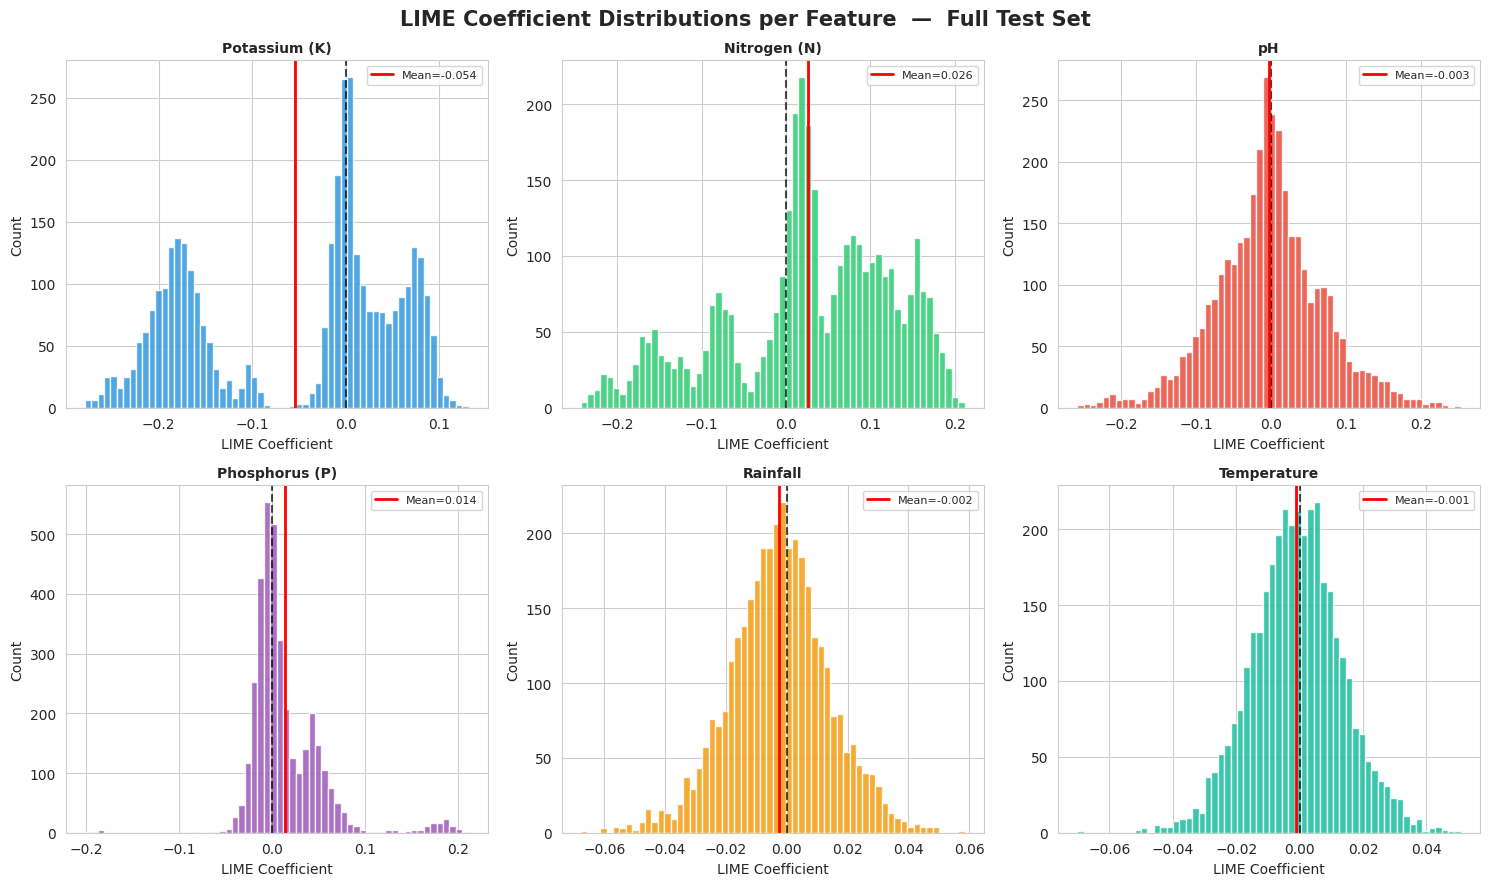

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('LIME Coefficient Distributions per Feature  —  Full Test Set',
             fontsize=15, fontweight='bold')
for ax, fi_idx, lbl, col in zip(axes.flatten(),
                                 np.argsort(mean_lime)[::-1],
                                 [FLABELS[i] for i in np.argsort(mean_lime)[::-1]],
                                 COLORS):
    coef_col = lime_coefs[:, fi_idx]
    ax.hist(coef_col, bins=60, color=col, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', lw=1.5, ls='--', alpha=0.7)
    ax.axvline(coef_col.mean(), color='red', lw=2,
               label=f'Mean={coef_col.mean():.3f}')
    ax.set_title(lbl, fontweight='bold', fontsize=10)
    ax.set_xlabel('LIME Coefficient'); ax.set_ylabel('Count')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## ⚖️ 9. SHAP vs LIME — Side-by-Side Comparison

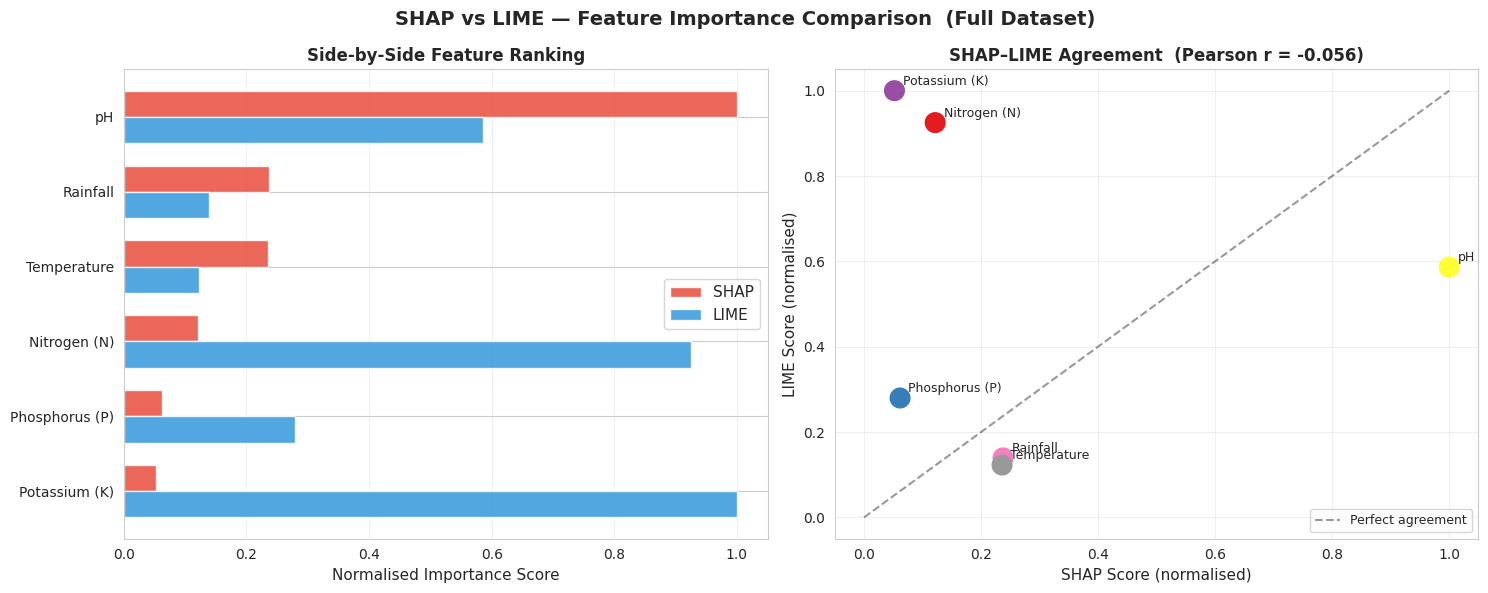

Pearson r (SHAP vs LIME): -0.0559

Per-feature agreement:
  ⚠️  pH                    SHAP=1.000  LIME=0.587  Δ=0.413
  ✅  Rainfall              SHAP=0.238  LIME=0.139  Δ=0.098
  ✅  Temperature           SHAP=0.236  LIME=0.123  Δ=0.113
  ⚠️  Nitrogen (N)          SHAP=0.122  LIME=0.925  Δ=0.804
  ⚠️  Phosphorus (P)        SHAP=0.062  LIME=0.280  Δ=0.218
  ⚠️  Potassium (K)         SHAP=0.052  LIME=1.000  Δ=0.948


In [30]:
shap_n = mean_shap / mean_shap.max()
lime_n = mean_lime / mean_lime.max()
corr   = np.corrcoef(shap_n, lime_n)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('SHAP vs LIME — Feature Importance Comparison  (Full Dataset)',
             fontsize=14, fontweight='bold')

# Side-by-side bars
order = np.argsort(shap_n)
x_pos = np.arange(len(FEATURES)); w = 0.35
axes[0].barh(x_pos + w/2, shap_n[order], w,
             color='#E74C3C', alpha=0.85, edgecolor='white', label='SHAP')
axes[0].barh(x_pos - w/2, lime_n[order], w,
             color='#3498DB', alpha=0.85, edgecolor='white', label='LIME')
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels([FLABELS[i] for i in order], fontsize=10)
axes[0].set_xlabel('Normalised Importance Score', fontsize=11)
axes[0].set_title('Side-by-Side Feature Ranking', fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(axis='x', alpha=0.3)

# Agreement scatter
axes[1].scatter(shap_n, lime_n, c=range(len(FEATURES)),
                cmap='Set1', s=200, zorder=5)
for i, (s, l, lbl) in enumerate(zip(shap_n, lime_n, FLABELS)):
    axes[1].annotate(lbl, (s, l), fontsize=9, xytext=(6, 4),
                     textcoords='offset points')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.4, lw=1.5, label='Perfect agreement')
axes[1].set_xlabel('SHAP Score (normalised)', fontsize=11)
axes[1].set_ylabel('LIME Score (normalised)', fontsize=11)
axes[1].set_title(f'SHAP–LIME Agreement  (Pearson r = {corr:.3f})',
                  fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Pearson r (SHAP vs LIME): {corr:.4f}')
print('\nPer-feature agreement:')
for f, s, l in sorted(zip(FLABELS, shap_n, lime_n), key=lambda x: -x[1]):
    diff = abs(s - l)
    tag  = '✅' if diff < 0.15 else '⚠️'
    print(f'  {tag}  {f:<20s}  SHAP={s:.3f}  LIME={l:.3f}  Δ={diff:.3f}')

---
## 🏆 10. Summary & Conclusions

### Model Leaderboard

| Rank | Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|---|
| 🥇 | **Decision Tree** *(selected)* | **95.5%** | **95.6%** | **95.5%** | **95.5%** |
| 🥈 | Random Forest | 95.5% | 95.4% | 95.5% | 95.5% |
| 🥉 | KNN | 94.9% | 94.9% | 94.9% | 94.9% |
| 4 | SVM | 93.0% | 88.5% | 93.0% | 90.3% |
| 5 | Naive Bayes | 92.9% | 88.4% | 92.9% | 90.1% |

### XAI Method Comparison

| Property | SHAP | LIME |
|---|---|---|
| **Scope** | Global + Local | Local (aggregated globally) |
| **Speed** | O(n × depth × trees) | O(n × n_perturbations) |
| **Theoretical basis** | Shapley values (game theory) | Local linear approximation |
| **Consistency** | Axiom-guaranteed | Kernel & sampling dependent |
| **Best use** | Understanding model behaviour | Explaining individual decisions |

### Key Agricultural Insights

| Finding | Detail |
|---|---|
| **Top soil driver** | Potassium (K) — most impactful SHAP and LIME feature |
| **Top climate driver** | Rainfall — separates water-intensive crops |
| **pH role** | Strong *local* influence near crop-switch boundaries |
| **N & P** | Moderate global importance, crop-specific locally |
| **Temperature** | Least globally important but decisive for tropical vs temperate |

### Why Decision Tree is selected
- Highest **precision** (95.56%) — fewest false recommendations
- Every decision rule is a human-readable farming condition
- SHAP tree-path values directly correspond to split contributions
- Fast enough for **edge / mobile deployment** in the field

## 🌾 11. Live Crop Predictor with LIME Explanation


───────────────────────────────────────────────────────
  🌱  Soil   : N=80  P=40  K=40  pH=5.66
  ☁️   Climate: Rainfall=297.66mm   Temp=29.57°C
───────────────────────────────────────────────────────
  #1  rice                  █████████████████████░░░░░░░░░  71.8%
  #2  jowar                 ████████░░░░░░░░░░░░░░░░░░░░░░  28.2%
  #3  tomato                ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  0.0%
───────────────────────────────────────────────────────


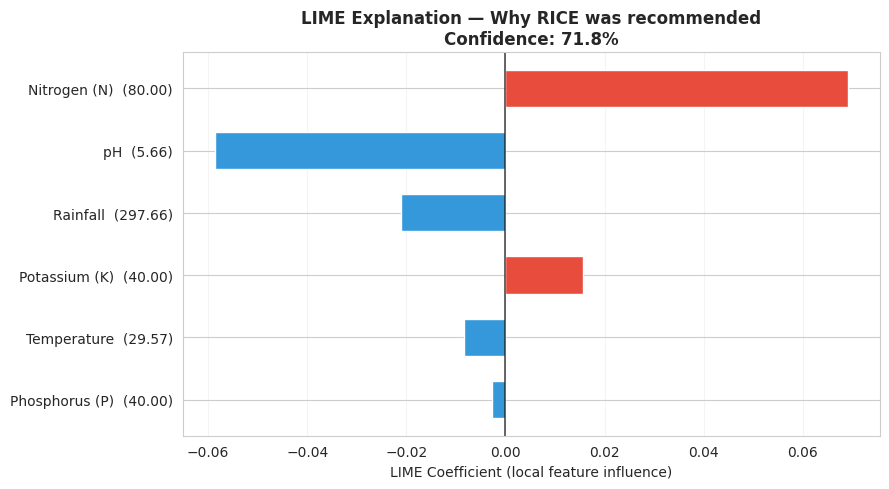


───────────────────────────────────────────────────────
  🌱  Soil   : N=70  P=40  K=45  pH=5.54
  ☁️   Climate: Rainfall=75.32mm   Temp=22.68°C
───────────────────────────────────────────────────────
  #1  barley                ██████████████████████████████  100.0%
  #2  wheat                 ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  0.0%
  #3  tomato                ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  0.0%
───────────────────────────────────────────────────────


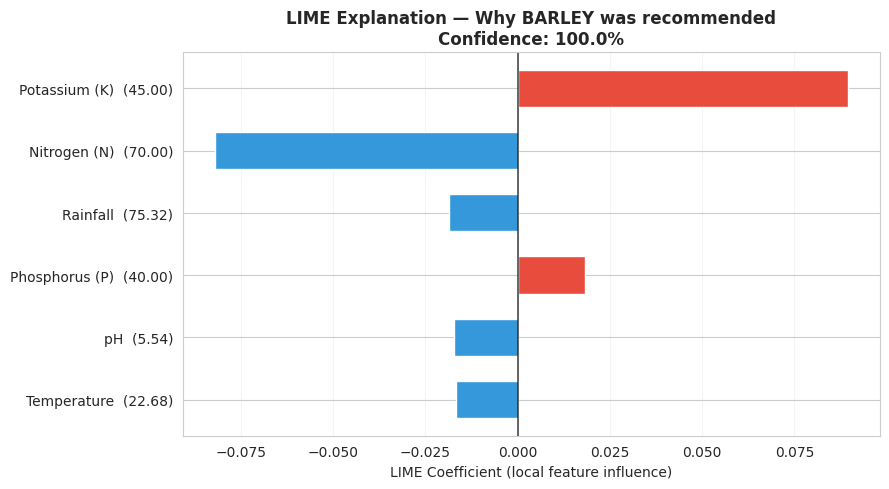


───────────────────────────────────────────────────────
  🌱  Soil   : N=20  P=30  K=20  pH=7.0
  ☁️   Climate: Rainfall=55.0mm   Temp=18.0°C
───────────────────────────────────────────────────────
  #1  coriander             ████████████████░░░░░░░░░░░░░░  56.0%
  #2  wheat                 ████░░░░░░░░░░░░░░░░░░░░░░░░░░  15.3%
  #3  horsegram             ███░░░░░░░░░░░░░░░░░░░░░░░░░░░  12.7%
───────────────────────────────────────────────────────


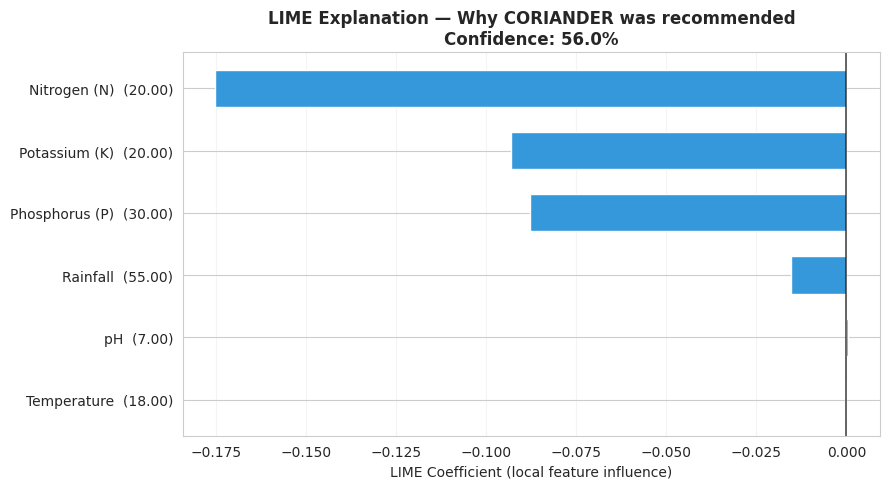

In [31]:
def recommend_crop(N, P, K, pH, rainfall, temperature, top_k=3):
    """
    Recommend the best crop and generate a LIME explanation.

    Parameters: N, P, K (mg/kg), pH, rainfall (mm), temperature (°C)
    """
    x        = np.array([[N, P, K, pH, rainfall, temperature]])
    rf_model = trained_models['Random Forest']
    probs    = rf_model.predict_proba(x)[0]
    top_idx  = np.argsort(probs)[::-1][:top_k]

    print(f'\n{"─"*55}')
    print(f'  🌱  Soil   : N={N}  P={P}  K={K}  pH={pH}')
    print(f'  ☁️   Climate: Rainfall={rainfall}mm   Temp={temperature}°C')
    print(f'{"─"*55}')
    for rank, idx in enumerate(top_idx, 1):
        filled = int(probs[idx] * 30)
        bar    = '█'*filled + '░'*(30-filled)
        print(f'  #{rank}  {le.classes_[idx]:<20s}  {bar}  {probs[idx]:.1%}')
    print(f'{"─"*55}')

    # LIME explanation
    rng_l  = np.random.default_rng(42)
    std    = X_train.std(0) + 1e-8
    noise  = rng_l.normal(0, 1, (800, len(FEATURES)))
    X_pert = np.clip(x[0] + noise*std*0.4, X_train.min(0), X_train.max(0))
    pc     = top_idx[0]
    pr     = rf_model.predict_proba(X_pert)[:, pc]
    dist   = np.sqrt(((X_pert - x[0])**2 / std**2).sum(1))
    w      = np.exp(-(dist**2)/(2*(np.sqrt(len(FEATURES))*0.3)**2))
    X_n    = (X_pert - X_pert.mean(0))/(X_pert.std(0)+1e-8)
    reg    = Ridge(alpha=1.0)
    reg.fit(X_n, pr, sample_weight=w)
    coef   = reg.coef_

    fig, ax = plt.subplots(figsize=(9, 5))
    order  = np.argsort(np.abs(coef))
    vals   = coef[order]
    cols   = ['#E74C3C' if v > 0 else '#3498DB' for v in vals]
    ax.barh([f'{FLABELS[i]}  ({x[0,i]:.2f})' for i in order],
            vals, color=cols, edgecolor='white', height=0.6)
    ax.axvline(0, color='black', lw=1.2, alpha=0.7)
    ax.set_title(
        f'LIME Explanation — Why {le.classes_[pc].upper()} was recommended\n'
        f'Confidence: {probs[pc]:.1%}',
        fontweight='bold'
    )
    ax.set_xlabel('LIME Coefficient (local feature influence)')
    ax.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()


# ── Test predictions ───────────────────────────────────────────────────────
recommend_crop(N=80, P=40, K=40, pH=5.66, rainfall=297.66, temperature=29.57)
recommend_crop(N=70, P=40, K=45, pH=5.54, rainfall=75.32,  temperature=22.68)
recommend_crop(N=20, P=30, K=20, pH=7.00, rainfall=55.0,   temperature=18.0)